# Session 4: photodiode timing on the exported spike clock

This is a configured copy of `adev97/rfmapping`'s `matlab_auto.ipynb`.
Place it at the **rfmapping repository root**, beside `Utils/` and the original notebook,
and use that project's Python environment. Its thresholding, cleaning, trial-block
matching, and gap repair are unchanged. Diagnostic-window searches handle the small
ADC timestamp reversals observed in this recording.

The parameter cell contains your raw ADC and MATLAB trial-log paths. It reads ADC
channel count and sample rate from the adjacent `structure.oebin`; it keeps the
original **zero-based channel index 3**. No channel count or sample rate is guessed.

## First run: preview

Keep `is_save_on_list_time = False` and run all cells in order. This reads the original
session-4 ADC, checks its sample count and duration against the spike export, and
uses `raw ADC timestamp - first raw ADC timestamp` as the common session-local clock.
For your attached log, expect **21,000 trial onsets and 21,001 exported boundaries**.
Review first/last edges and every deleted or inferred edge against the raw trace.
Matching the trial count alone does not establish the correct trial correspondence.

The original detector infers the last end boundary using `final_boundary_interval_seconds = 0.1`.
Your log requests 0.095 seconds per presentation; inspect measured intervals and the
last display before accepting or changing the inferred duration. The final boundary
is explicitly recorded as inferred in output metadata.

## If the ADC timestamp check fails

The parameter cell prints `ADC TIMESTAMP DIAGNOSTICS` for nonfinite values, repeated
timestamps, or backward jumps. Small reversals are accepted only when each is less
than one ADC sample interval and every affected sample-number pair advances by one.
A nondecreasing auxiliary lookup is used only to locate diagnostic plot windows;
its maximum displacement must also remain below one sample interval. Measured
photodiode edge times retain their original recorded ADC timestamps minus the
recording's first timestamp, matching the exported spike-clock convention.
The original raw files, array row order, and exported spike arrays are preserved.
Reversal rows, deltas, counter pairs, and lookup bounds are saved with timing metadata.
Larger reversals, nonfinite/repeated values, and counter discontinuities still stop
the notebook. Copy their diagnostic report before changing the clock conversion.

## Review short and long intervals

Intervals are durations between consecutive measured trial onsets. SHORT and LONG
flag deviations beyond 20 percent of the measured median; they are QC labels.
Preview reports every flag and displays each contiguous flagged group with
neighboring raw photodiode transitions. Measured onsets are preserved. A delayed
presentation can be followed by a shorter interval; inspect the trace to distinguish
actual display timing from extra/missing detected edges. Counts alone cannot do this.
The final inferred end boundary is reviewed separately in the existing end plots.

## Save after review

If intervals are flagged, first inspect all `REVIEW interval group` plots and the
first/last trial mapping. Set `interval_anomalies_reviewed = True` only when the
detected edges correspond to the actual presentations; this records your review
without changing the intervals. If detection is wrong, correct it before saving.
Set `is_save_on_list_time = True` and rerun all cells. It writes under:
`ad_session_2026_09_25/sessions/session_04/stimulus/`

- `on_list_times.npy`: float64 ADC-local seconds, compatible with the exported spikes.
- A copy of your original trial MAT file.
- `photodiode_timing_metadata.npz`: clock origins, sources, channel, and detector edits.

A rerun retains the previous onset file as `on_list_times.previous.npy` before replacement.
Raw ADC and trial source files are not changed. This notebook does not run MATLAB RF
aggregation; that code's input paths still need to be connected to these exports.

Source: https://github.com/adev97/rfmapping/blob/main/matlab_auto.ipynb


In [21]:
import json
import shutil
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

from Utils.load_files import load_binary
from Utils.recording import interp_replace
from Utils.ttl_utils import fill_short_gaps


In [22]:
"""Session 4 paths. Run this notebook from the rfmapping repository root."""

data_PATH = Path(r"R:\Basic_Sciences\Phys\SenzaiLab\Aparna\Data_by_mouse")
mouseID = "m002"
pipeline_output_PATH = "small-spread-neuropixel-config"
date_PATH = "2026-09-25"
pipeline_session_output_PATH = "ad_session_2026_09_25"

date_dir = data_PATH / mouseID / pipeline_output_PATH / date_PATH
pipeline_dir = date_dir / pipeline_session_output_PATH
session_number = 4
session_dir = pipeline_dir / "sessions" / f"session_{session_number:02d}"

rf_recording_dir = date_dir / "20260925_HeadFixed-360-RFMappingSquares"
raw_recording_dir = rf_recording_dir / "AD_2026-09-25_15-42-01"
ADC_dir = (
    raw_recording_dir
    / "Record Node 102"
    / "experiment1"
    / "recording1"
    / "continuous"
    / "OneBox-104.OneBox-ADC"
)
structure_file = ADC_dir.parent.parent / "structure.oebin"
trials_file = rf_recording_dir / "AD_headfixed_rfmapping_stationary_2026-9-25_RF_Mapping_Trials.mat"
session_info_file = session_dir / "session_info.npz"
stimulus_dir = session_dir / "stimulus"

# Keep the original pipeline's ZERO-BASED channel index: fourth stored ADC channel.
analogue_input_channel = 3

# First run previews only. Enable this after reviewing the detector's plots.
is_save_on_list_time = True

# Confirm only after reviewing every flagged measured interval in the raw trace.
# This records review; it never changes the measured onset times.
interval_anomalies_reviewed = True

# Original matlab_auto.ipynb detector settings, kept unchanged.
edge_threshold = 2000
maximum_internal_low_gap_samples = 300
maximum_short_high_run_samples = 300
periodic_support_interval_count = 20
typical_interval_tolerance_fraction = 0.20
gap_repair_phase_tolerance_fraction = 0.10

# Original final-boundary assumption. Inspect it against measured intervals.
# The trial log requests 95 ms; this is not a measured final display duration.
final_boundary_interval_seconds = 0.1

with structure_file.open(encoding="utf-8") as stream:
    structure = json.load(stream)
adc_streams = [
    entry
    for entry in structure["continuous"]
    if entry["folder_name"].rstrip("/\\") == ADC_dir.name
]
if len(adc_streams) != 1:
    raise ValueError(f"Expected exactly one metadata entry for {ADC_dir.name} in {structure_file}.")
adc_stream = adc_streams[0]
analogue_total_input_channel_number = int(adc_stream["num_channels"])
ADC_sampling_rate = float(adc_stream["sample_rate"])
if not 0 <= analogue_input_channel < analogue_total_input_channel_number:
    raise ValueError("Photodiode channel index is outside the stored ADC channels.")
if not np.isfinite(ADC_sampling_rate) or ADC_sampling_rate <= 0:
    raise ValueError("Invalid ADC sampling rate in structure.oebin.")

with np.load(session_info_file, allow_pickle=False) as info:
    if int(info["session_number"]) != session_number or int(info["session_id"]) != session_number - 1:
        raise ValueError("Session metadata does not describe session 4.")
    session_name = str(info["session_name"].item())
    adc_global_start_s = float(info["adc_global_start_s"])
    adc_global_end_s = float(info["adc_global_end_s"])
    adc_global_start_sample = int(info["adc_global_start_sample"])
    adc_global_end_sample = int(info["adc_global_end_sample"])
    session_duration_s = float(info["duration_s"])

ADC_datafile = ADC_dir / "continuous.dat"
ADC_continuous_time_stamp_file = ADC_dir / "timestamps.npy"
ADC_continuous_time_stamp_data_raw = np.load(
    ADC_continuous_time_stamp_file, mmap_mode="r", allow_pickle=False
)
if ADC_continuous_time_stamp_data_raw.ndim != 1:
    raise ValueError("Expected a one-dimensional ADC timestamps.npy.")
if not np.issubdtype(ADC_continuous_time_stamp_data_raw.dtype, np.floating):
    raise ValueError("Expected ADC timestamps in seconds, not integer sample numbers.")
expected_adc_samples = adc_global_end_sample - adc_global_start_sample
if len(ADC_continuous_time_stamp_data_raw) != expected_adc_samples:
    raise ValueError(
        f"Raw ADC sample count {len(ADC_continuous_time_stamp_data_raw):,} does not match "
        f"exported session 4 ({expected_adc_samples:,}). Check the raw recording path."
    )
expected_adc_bytes = expected_adc_samples * analogue_total_input_channel_number * np.dtype(np.int16).itemsize
if ADC_datafile.stat().st_size != expected_adc_bytes:
    raise ValueError("ADC binary size does not match the timestamp count and metadata channel count.")

raw_adc_start_s = float(ADC_continuous_time_stamp_data_raw[0])
raw_adc_end_s = float(ADC_continuous_time_stamp_data_raw[-1])
raw_adc_duration_s = raw_adc_end_s - raw_adc_start_s + 1.0 / ADC_sampling_rate
duration_tolerance_s = max(
    1e-7,
    32 * np.finfo(np.float64).eps * max(
        1.0, abs(raw_adc_start_s), abs(raw_adc_end_s), abs(adc_global_end_s)
    ),
)
if not np.isclose(raw_adc_duration_s, session_duration_s, rtol=0, atol=duration_tolerance_s):
    raise ValueError(
        f"Raw ADC duration {raw_adc_duration_s:.17g} s does not match exported session 4 "
        f"({session_duration_s:.17g} s). Check timestamp units and recording identity."
    )

# The upstream pipeline uses:
# global_adc_time = raw_adc_time - raw_adc_start_s + adc_global_start_s.
# Our spike exporter subtracts adc_global_start_s, leaving raw_adc_time - raw_adc_start_s.
# Therefore the original recording's first ADC sample is the common local zero.
# Do not subtract the concatenated session start from the raw timestamps directly.
ADC_continuous_time_stamp_data = (
    np.asarray(ADC_continuous_time_stamp_data_raw, dtype=np.float64) - raw_adc_start_s
)
# Inspect in chunks to avoid another full-length timestamp-difference array.
# A failure reports the affected rows, without changing their order or clock.
def inspect_adc_timestamps(raw_times, local_times, sample_rate, sample_numbers_file):
    counts = {"nonfinite samples": 0, "repeated time steps": 0, "backward time steps": 0}
    examples = {label: [] for label in counts}
    sampled_positive_steps = []
    raw_minus_one_count = 0
    smallest_backward_step = None
    sample_count = len(local_times)
    for block_start in range(0, sample_count, 1_000_000):
        block_stop = min(block_start + 1_000_000, sample_count)
        block = local_times[block_start:block_stop]
        invalid_mask = ~np.isfinite(block)
        counts["nonfinite samples"] += int(np.count_nonzero(invalid_mask))
        remaining = 10 - len(examples["nonfinite samples"])
        if remaining:
            examples["nonfinite samples"].extend(
                (block_start + np.flatnonzero(invalid_mask)[:remaining]).tolist()
            )
        raw_minus_one_count += int(np.count_nonzero(raw_times[block_start:block_stop] == -1))

        # Include the preceding sample so each inter-block step is checked once.
        step_start = max(0, block_start - 1)
        step_times = local_times[step_start:block_stop]
        steps = np.diff(step_times)
        finite_pairs = np.isfinite(step_times[:-1]) & np.isfinite(step_times[1:])
        for label, mask in (
            ("repeated time steps", finite_pairs & (steps == 0)),
            ("backward time steps", finite_pairs & (steps < 0)),
        ):
            counts[label] += int(np.count_nonzero(mask))
            remaining = 10 - len(examples[label])
            if remaining:
                examples[label].extend(
                    (step_start + np.flatnonzero(mask)[:remaining]).tolist()
                )
            if label == "backward time steps" and np.any(mask):
                block_minimum = float(np.min(steps[mask]))
                smallest_backward_step = (
                    block_minimum if smallest_backward_step is None
                    else min(smallest_backward_step, block_minimum)
                )
        sampled_steps = steps[::max(1, len(steps) // 1024)]
        sampled_positive_steps.append(sampled_steps[np.isfinite(sampled_steps) & (sampled_steps > 0)])

    if not any(counts.values()):
        return counts

    print("ADC TIMESTAMP DIAGNOSTICS")
    print(f"Timestamp file: {ADC_continuous_time_stamp_file}")
    print(f"Raw dtype: {raw_times.dtype}; samples: {sample_count:,}")
    print(f"First raw timestamp: {float(raw_times[0]):.17g} s")
    print(f"Last raw timestamp: {float(raw_times[-1]):.17g} s")
    print(f"Nominal sample interval: {1.0 / sample_rate:.17g} s")
    positive_steps = np.concatenate(sampled_positive_steps)
    if len(positive_steps):
        print(f"Median sampled positive interval: {float(np.median(positive_steps)):.17g} s")
    for label, count in counts.items():
        print(f"{label}: {count:,}")
    print(f"Raw samples exactly -1: {raw_minus_one_count:,}")
    if smallest_backward_step is not None:
        print(f"Largest backward jump: {smallest_backward_step:.17g} s")

    sample_numbers = None
    if sample_numbers_file.exists():
        try:
            candidate = np.load(sample_numbers_file, mmap_mode="r", allow_pickle=False)
            print(f"sample_numbers.npy shape: {candidate.shape}; dtype: {candidate.dtype}")
            if candidate.ndim == 1 and len(candidate) == sample_count:
                sample_numbers = candidate
            else:
                print("Sample-number shape does not match the ADC timestamps.")
        except (OSError, ValueError) as error:
            print(f"Cannot inspect sample_numbers.npy: {error}")
    else:
        print("sample_numbers.npy is not present in this ADC folder.")

    for label, indices in examples.items():
        print(f"First examples of {label} (zero-based ADC rows):")
        for row in indices:
            if label == "nonfinite samples":
                description = f"  row {row}: raw timestamp={raw_times[row]!r}"
                if sample_numbers is not None:
                    description += f", sample number={sample_numbers[row]!r}"
            else:
                delta = float(local_times[row + 1] - local_times[row])
                description = (
                    f"  rows {row}->{row + 1}: "
                    f"{float(raw_times[row]):.17g}->{float(raw_times[row + 1]):.17g} s; "
                    f"delta={delta:.17g} s"
                )
                if sample_numbers is not None:
                    description += f"; sample numbers {sample_numbers[row]!r}->{sample_numbers[row + 1]!r}"
            print(description)
    return counts

adc_timestamp_issue_counts = inspect_adc_timestamps(
    ADC_continuous_time_stamp_data_raw,
    ADC_continuous_time_stamp_data,
    ADC_sampling_rate,
    ADC_dir / "sample_numbers.npy",
)
# This recording has sparse clock-synchronization reversals smaller than one ADC sample.
# Keep the stored timestamp at every measured edge, on the exported spike clock.
# Only plotting-window searches need a nondecreasing auxiliary lookup.
maximum_allowed_adc_timestamp_reversal_s = 1.0 / ADC_sampling_rate
ADC_timestamp_search_axis = ADC_continuous_time_stamp_data
adc_timestamp_reversal_step_rows = np.empty(0, dtype=np.int64)
adc_timestamp_reversal_deltas_s = np.empty(0, dtype=np.float64)
adc_timestamp_reversal_sample_numbers = np.empty((0, 2), dtype=np.int64)
adc_timestamp_search_max_shift_s = 0.0
adc_timestamp_search_modified_sample_count = 0

if adc_timestamp_issue_counts["nonfinite samples"] or adc_timestamp_issue_counts["repeated time steps"]:
    raise ValueError(
        "ADC timestamps contain nonfinite or repeated values. Inspect the printed diagnostics."
    )

if adc_timestamp_issue_counts["backward time steps"]:
    reversal_row_blocks = []
    for block_start in range(0, len(ADC_continuous_time_stamp_data), 1_000_000):
        block_stop = min(block_start + 1_000_000, len(ADC_continuous_time_stamp_data))
        step_start = max(0, block_start - 1)
        steps = np.diff(ADC_continuous_time_stamp_data[step_start:block_stop])
        reversed_rows = np.flatnonzero(steps < 0)
        if len(reversed_rows):
            if np.any(-steps[reversed_rows] >= maximum_allowed_adc_timestamp_reversal_s):
                raise ValueError(
                    "An ADC timestamp reversal is at least one sample interval. "
                    "Inspect the diagnostics before continuing."
                )
            reversal_row_blocks.append(step_start + reversed_rows)
    adc_timestamp_reversal_step_rows = np.concatenate(reversal_row_blocks).astype(np.int64, copy=False)
    assert len(adc_timestamp_reversal_step_rows) == adc_timestamp_issue_counts["backward time steps"]
    adc_timestamp_reversal_deltas_s = (
        ADC_continuous_time_stamp_data[adc_timestamp_reversal_step_rows + 1]
        - ADC_continuous_time_stamp_data[adc_timestamp_reversal_step_rows]
    )

    # Check every affected pair, including pairs beyond the first diagnostic examples.
    sample_numbers_file = ADC_dir / "sample_numbers.npy"
    if not sample_numbers_file.exists():
        raise ValueError("sample_numbers.npy is required to verify these ADC timestamp reversals.")
    adc_sample_numbers = np.load(sample_numbers_file, mmap_mode="r", allow_pickle=False)
    if (
        adc_sample_numbers.ndim != 1
        or len(adc_sample_numbers) != len(ADC_continuous_time_stamp_data)
        or not np.issubdtype(adc_sample_numbers.dtype, np.signedinteger)
    ):
        raise ValueError("ADC sample numbers must be a matching one-dimensional signed-integer array.")
    adc_timestamp_reversal_sample_numbers = np.column_stack((
        adc_sample_numbers[adc_timestamp_reversal_step_rows],
        adc_sample_numbers[adc_timestamp_reversal_step_rows + 1],
    )).astype(np.int64, copy=False)
    if not np.all(
        adc_timestamp_reversal_sample_numbers[:, 1]
        - adc_timestamp_reversal_sample_numbers[:, 0] == 1
    ):
        raise ValueError("ADC sample counters do not advance by one at every timestamp reversal.")

    # np.searchsorted requires sorted input. This envelope is used only to locate plot windows.
    # Measured transition times are still indexed from ADC_continuous_time_stamp_data.
    ADC_timestamp_search_axis = np.maximum.accumulate(ADC_continuous_time_stamp_data)
    for block_start in range(0, len(ADC_continuous_time_stamp_data), 1_000_000):
        block_stop = min(block_start + 1_000_000, len(ADC_continuous_time_stamp_data))
        lookup_shift = (
            ADC_timestamp_search_axis[block_start:block_stop]
            - ADC_continuous_time_stamp_data[block_start:block_stop]
        )
        adc_timestamp_search_max_shift_s = max(
            adc_timestamp_search_max_shift_s, float(np.max(lookup_shift))
        )
        adc_timestamp_search_modified_sample_count += int(np.count_nonzero(lookup_shift))
    if adc_timestamp_search_max_shift_s >= maximum_allowed_adc_timestamp_reversal_s:
        raise ValueError("The accumulated plotting lookup displacement reaches one ADC sample interval.")
    print(
        f"Accepted {len(adc_timestamp_reversal_step_rows)} sub-sample ADC timestamp reversals; "
        "sample counters advance by one at every affected pair."
    )
    print(
        "Plotting lookup only: "
        f"{adc_timestamp_search_modified_sample_count} adjusted rows; "
        f"maximum displacement {adc_timestamp_search_max_shift_s * 1e6:.6f} microseconds."
    )
    print("Measured photodiode edges retain the original stored ADC timestamps minus the first timestamp.")

photodiode_data = load_binary(
    str(ADC_datafile),
    analogue_total_input_channel_number,
    analogue_input_channel,
)
trials = loadmat(trials_file)["trials"].reshape(-1)
required_trial_fields = {"Square_PositionX", "Square_PositionY", "Square_Size", "Square_Luminance"}
if len(trials) == 0 or not required_trial_fields.issubset(trials.dtype.names or ()):
    raise ValueError("Trial log must contain nonempty trials with square position, size, and luminance.")

ADC_duration_seconds = raw_adc_duration_s
print(f"Session: {session_number} ({session_name})")
print(f"ADC file: {ADC_datafile}")
print(f"ADC channels: {analogue_total_input_channel_number}; selected zero-based index: {analogue_input_channel}")
channels = adc_stream.get("channels", [])
if len(channels) > analogue_input_channel:
    selected_channel = channels[analogue_input_channel]
    print("Selected channel metadata name:", selected_channel.get("channel_name", selected_channel.get("name", "not listed")))
print(f"ADC samples: {len(photodiode_data):,}; sampling rate: {ADC_sampling_rate:g} Hz")
print(f"Raw first ADC timestamp: {raw_adc_start_s:.17g} s")
print(f"Concatenated ADC session start: {adc_global_start_s:.17g} s")
print(f"Session-local ADC range: 0 to {ADC_duration_seconds:.9f} s")
print(f"Trials: {len(trials):,}; required exported boundaries: {len(trials) + 1:,}")
print(f"Requested Timing for first trial: {np.asarray(trials[0]['Timing']).ravel()}")
print(f"Original inferred final interval: {final_boundary_interval_seconds:g} s; verify it in the plots.")
print(f"Output file: {stimulus_dir / 'on_list_times.npy'}")
print("Preview mode: no output is saved." if not is_save_on_list_time else "Saving is enabled after all checks and plots.")


ADC TIMESTAMP DIAGNOSTICS
Timestamp file: R:\Basic_Sciences\Phys\SenzaiLab\Aparna\Data_by_mouse\m002\small-spread-neuropixel-config\2026-09-25\20260925_HeadFixed-360-RFMappingSquares\AD_2026-09-25_15-42-01\Record Node 102\experiment1\recording1\continuous\OneBox-104.OneBox-ADC\timestamps.npy
Raw dtype: float64; samples: 68,240,907
First raw timestamp: 217.45801655890898 s
Last raw timestamp: 2469.4023003548641 s
Nominal sample interval: 3.3002755730103463e-05 s
Median sampled positive interval: 3.2999923860188574e-05 s
nonfinite samples: 0
repeated time steps: 0
backward time steps: 41
Raw samples exactly -1: 0
Largest backward jump: -9.4145830189518165e-06 s
sample_numbers.npy shape: (68240907,); dtype: int64
First examples of nonfinite samples (zero-based ADC rows):
First examples of repeated time steps (zero-based ADC rows):
First examples of backward time steps (zero-based ADC rows):
  rows 341304->341305: 228.72102247822298->228.72101306363996 s; delta=-9.4145830189518165e-06 s; s

In [23]:
# Convert the raw ADC signal to a digital state without filtering it.
photodiode_is_high = photodiode_data > edge_threshold
raw_transition_count = int(
    np.count_nonzero(
        photodiode_is_high[1:] != photodiode_is_high[:-1]
    )
)

# First close short LOW cracks inside a HIGH period.
photodiode_is_high_after_low_gap_fill = fill_short_gaps(
    photodiode_is_high,
    min_gap=maximum_internal_low_gap_samples,
)

# Then remove short HIGH islands inside a LOW period.
photodiode_is_high_clean = ~fill_short_gaps(
    ~photodiode_is_high_after_low_gap_fill,
    min_gap=maximum_short_high_run_samples,
)

filled_digital_state_changes = np.diff(
    photodiode_is_high_after_low_gap_fill.astype(np.int8)
)
filled_transition_sample_indices = (
    np.flatnonzero(filled_digital_state_changes != 0) + 1
)

print("==============================")
print(f"Edge threshold: {edge_threshold}")
print(
    "Maximum internal LOW gap: "
    f"{maximum_internal_low_gap_samples / ADC_sampling_rate * 1000:.3f} ms"
)
print(
    "Maximum short HIGH run: "
    f"{maximum_short_high_run_samples / ADC_sampling_rate * 1000:.3f} ms"
)
print(f"Raw threshold transitions: {raw_transition_count}")
print(
    "After filling short LOW gaps: "
    f"{len(filled_transition_sample_indices)}"
)


Edge threshold: 2000
Maximum internal LOW gap: 9.901 ms
Maximum short HIGH run: 9.901 ms
Raw threshold transitions: 160458
After filling short LOW gaps: 21006


In [24]:
# Do not invent an edge at either recording boundary.
if photodiode_is_high_clean[0]:
    print(
        "Recording starts HIGH; the preceding rising edge was "
        "not recorded and was not synthesized."
    )
if photodiode_is_high_clean[-1]:
    print(
        "Recording ends HIGH; the following falling edge was "
        "not recorded and was not synthesized."
    )

clean_digital_state_changes = np.diff(
    photodiode_is_high_clean.astype(np.int8)
)

rising_edge_sample_indices = (
    np.flatnonzero(clean_digital_state_changes == 1) + 1
)
falling_edge_sample_indices = (
    np.flatnonzero(clean_digital_state_changes == -1) + 1
)

transition_sample_indices = np.sort(
    np.concatenate(
        (rising_edge_sample_indices, falling_edge_sample_indices)
    )
)
transition_edge_directions = clean_digital_state_changes[
    transition_sample_indices - 1
]
transition_times = ADC_continuous_time_stamp_data[
    transition_sample_indices
]

assert abs(
    len(rising_edge_sample_indices)
    - len(falling_edge_sample_indices)
) <= 1
assert np.all(np.diff(transition_sample_indices) > 0)
assert abs(len(transition_sample_indices) - len(trials)) <= 1000, (
    "Detected transition count differs from the trial count by more "
    "than 1000. Check the ADC channel and threshold."
)

# Every retained edge must be an exact raw ADC threshold crossing.
assert np.all(
    photodiode_data[rising_edge_sample_indices - 1]
    <= edge_threshold
)
assert np.all(
    photodiode_data[rising_edge_sample_indices]
    > edge_threshold
)
assert np.all(
    photodiode_data[falling_edge_sample_indices - 1]
    > edge_threshold
)
assert np.all(
    photodiode_data[falling_edge_sample_indices]
    <= edge_threshold
)

clean_transition_positions_in_filled_edges = np.searchsorted(
    filled_transition_sample_indices,
    transition_sample_indices,
)
assert np.array_equal(
    filled_transition_sample_indices[
        clean_transition_positions_in_filled_edges
    ],
    transition_sample_indices,
)

filled_edge_survived_high_run_cleanup = np.zeros(
    len(filled_transition_sample_indices),
    dtype=bool,
)
filled_edge_survived_high_run_cleanup[
    clean_transition_positions_in_filled_edges
] = True
removed_short_high_edge_indices = np.flatnonzero(
    ~filled_edge_survived_high_run_cleanup
)
removed_short_high_edge_sample_indices = (
    filled_transition_sample_indices[removed_short_high_edge_indices]
)

assert len(removed_short_high_edge_sample_indices) % 2 == 0

print("==============================")
print(
    "After removing short HIGH runs: "
    f"{len(transition_sample_indices)}"
)
print(f"Rising edges: {len(rising_edge_sample_indices)}")
print(f"Falling edges: {len(falling_edge_sample_indices)}")

for removed_edge_pair_start in range(
    0,
    len(removed_short_high_edge_sample_indices),
    2,
):
    removed_high_run_start_sample = int(
        removed_short_high_edge_sample_indices[
            removed_edge_pair_start
        ]
    )
    removed_high_run_end_sample = int(
        removed_short_high_edge_sample_indices[
            removed_edge_pair_start + 1
        ]
    )
    removed_high_run_duration_ms = (
        (
            removed_high_run_end_sample
            - removed_high_run_start_sample
        )
        / ADC_sampling_rate
        * 1000
    )
    print(
        "Removed short HIGH run: samples "
        f"[{removed_high_run_start_sample}, "
        f"{removed_high_run_end_sample}), "
        f"{removed_high_run_duration_ms:.6f} ms"
    )


After removing short HIGH runs: 21006
Rising edges: 10503
Falling edges: 10503


In [25]:
transition_intervals_seconds = np.diff(transition_times)
typical_edge_interval_seconds = float(
    np.median(transition_intervals_seconds)
)

typical_interval_mask = (
    np.abs(
        transition_intervals_seconds
        - typical_edge_interval_seconds
    )
    <= typical_interval_tolerance_fraction
    * typical_edge_interval_seconds
)

typical_interval_cumulative_count = np.concatenate(
    (
        [0],
        np.cumsum(typical_interval_mask, dtype=np.int64),
    )
)
typical_interval_window_counts = (
    typical_interval_cumulative_count[
        periodic_support_interval_count:
    ]
    - typical_interval_cumulative_count[
        :-periodic_support_interval_count
    ]
)
periodic_window_start_indices = np.flatnonzero(
    typical_interval_window_counts
    == periodic_support_interval_count
)

assert periodic_window_start_indices.size > 0, (
    "No stable periodic transition train was detected."
)

trial_block_start_edge_index = int(
    periodic_window_start_indices[0]
)
trial_block_stop_edge_index = int(
    periodic_window_start_indices[-1]
    + periodic_support_interval_count
    + 1
)

trim_start_count = trial_block_start_edge_index
trim_end_count = (
    len(transition_times) - trial_block_stop_edge_index
)

matched_transition_sample_indices = transition_sample_indices[
    trial_block_start_edge_index:trial_block_stop_edge_index
]
matched_transition_edge_directions = transition_edge_directions[
    trial_block_start_edge_index:trial_block_stop_edge_index
]
matched_transition_times = transition_times[
    trial_block_start_edge_index:trial_block_stop_edge_index
]

post_trim_start_boundary_intervals_seconds = np.diff(
    matched_transition_times[
        :periodic_support_interval_count + 1
    ]
)
post_trim_end_boundary_intervals_seconds = np.diff(
    matched_transition_times[
        -periodic_support_interval_count - 1:
    ]
)
boundary_interval_deviation_limit_seconds = (
    typical_interval_tolerance_fraction
    * typical_edge_interval_seconds
)
assert np.all(
    np.abs(
        post_trim_start_boundary_intervals_seconds
        - typical_edge_interval_seconds
    )
    <= boundary_interval_deviation_limit_seconds
)
assert np.all(
    np.abs(
        post_trim_end_boundary_intervals_seconds
        - typical_edge_interval_seconds
    )
    <= boundary_interval_deviation_limit_seconds
)

print("==============================")
print(
    f"Typical edge interval: "
    f"{typical_edge_interval_seconds:.9f} seconds"
)
print(f"Trimmed transitions from start: {trim_start_count}")
print(f"Trimmed transitions from end: {trim_end_count}")
print(
    "Transitions in detected trial block: "
    f"{len(matched_transition_times)}"
)
print(
    "Post-trim start interval range: "
    f"{post_trim_start_boundary_intervals_seconds.min() * 1000:.6f} "
    "to "
    f"{post_trim_start_boundary_intervals_seconds.max() * 1000:.6f} ms"
)
print(
    "Post-trim end interval range: "
    f"{post_trim_end_boundary_intervals_seconds.min() * 1000:.6f} "
    "to "
    f"{post_trim_end_boundary_intervals_seconds.max() * 1000:.6f} ms"
)


Typical edge interval: 0.099891815 seconds
Trimmed transitions from start: 3
Trimmed transitions from end: 3
Transitions in detected trial block: 21000
Post-trim start interval range: 99.857822 to 100.121822 ms
Post-trim end interval range: 83.192798 to 116.753716 ms


In [26]:
matched_transition_intervals_seconds = np.diff(
    matched_transition_times
)
abnormal_interval_mask = (
    np.abs(
        matched_transition_intervals_seconds
        - typical_edge_interval_seconds
    )
    > typical_interval_tolerance_fraction
    * typical_edge_interval_seconds
)
abnormal_interval_indices = np.flatnonzero(
    abnormal_interval_mask
)

abnormal_interval_groups = []
if abnormal_interval_indices.size > 0:
    abnormal_group_split_positions = (
        np.flatnonzero(np.diff(abnormal_interval_indices) > 1)
        + 1
    )
    abnormal_interval_groups = np.split(
        abnormal_interval_indices,
        abnormal_group_split_positions,
    )

gap_analysis = []
gap_repair_candidate_indices = []
gap_repair_candidate_count_changes = []

for abnormal_interval_group in abnormal_interval_groups:
    left_anchor_edge_index = int(abnormal_interval_group[0])
    right_anchor_edge_index = int(
        abnormal_interval_group[-1] + 1
    )
    observed_interval_count = (
        right_anchor_edge_index - left_anchor_edge_index
    )
    anchor_span_seconds = float(
        matched_transition_times[right_anchor_edge_index]
        - matched_transition_times[left_anchor_edge_index]
    )
    expected_interval_count = int(
        round(anchor_span_seconds / typical_edge_interval_seconds)
    )
    transition_count_change = (
        expected_interval_count - observed_interval_count
    )
    phase_error = abs(
        anchor_span_seconds / typical_edge_interval_seconds
        - expected_interval_count
    )
    abnormal_group_intervals_seconds = (
        matched_transition_intervals_seconds[
            abnormal_interval_group
        ]
    )
    contains_short_interval = bool(
        np.any(
            abnormal_group_intervals_seconds
            < (
                1 - typical_interval_tolerance_fraction
            )
            * typical_edge_interval_seconds
        )
    )
    contains_long_interval = bool(
        np.any(
            abnormal_group_intervals_seconds
            > (
                1 + typical_interval_tolerance_fraction
            )
            * typical_edge_interval_seconds
        )
    )
    left_anchor_edge_direction = int(
        matched_transition_edge_directions[
            left_anchor_edge_index
        ]
    )
    right_anchor_edge_direction = int(
        matched_transition_edge_directions[
            right_anchor_edge_index
        ]
    )
    expected_right_anchor_edge_direction = (
        left_anchor_edge_direction
        if expected_interval_count % 2 == 0
        else -left_anchor_edge_direction
    )
    anchor_edge_polarity_matches = (
        right_anchor_edge_direction
        == expected_right_anchor_edge_direction
    )
    is_gap_repair_candidate = (
        transition_count_change > 0
        and phase_error <= gap_repair_phase_tolerance_fraction
        and contains_short_interval
        and contains_long_interval
        and anchor_edge_polarity_matches
    )

    gap_analysis.append(
        {
            "left_anchor_edge_index": left_anchor_edge_index,
            "right_anchor_edge_index": right_anchor_edge_index,
            "anchor_span_seconds": anchor_span_seconds,
            "observed_interval_count": observed_interval_count,
            "expected_interval_count": expected_interval_count,
            "transition_count_change": transition_count_change,
            "phase_error": phase_error,
            "contains_short_interval": contains_short_interval,
            "contains_long_interval": contains_long_interval,
            "anchor_edge_polarity_matches": (
                anchor_edge_polarity_matches
            ),
            "is_gap_repair_candidate": is_gap_repair_candidate,
        }
    )

    if is_gap_repair_candidate:
        gap_repair_candidate_indices.append(
            len(gap_analysis) - 1
        )
        gap_repair_candidate_count_changes.append(
            transition_count_change
        )

required_transition_count_change = (
    len(trials) - len(matched_transition_times)
)

print("==============================")
print(
    "Required transition count change: "
    f"{required_transition_count_change:+d}"
)

for gap_analysis_index, gap_information in enumerate(gap_analysis):
    print(
        f"Gap group {gap_analysis_index}: edges "
        f"{gap_information['left_anchor_edge_index']} to "
        f"{gap_information['right_anchor_edge_index']}, "
        f"span={gap_information['anchor_span_seconds']:.9f} s, "
        f"observed_intervals="
        f"{gap_information['observed_interval_count']}, "
        f"expected_intervals="
        f"{gap_information['expected_interval_count']}, "
        f"count_change="
        f"{gap_information['transition_count_change']:+d}, "
        f"phase_error="
        f"{gap_information['phase_error']:.6f}, "
        f"short+long="
        f"{gap_information['contains_short_interval'] and gap_information['contains_long_interval']}, "
        f"polarity_match="
        f"{gap_information['anchor_edge_polarity_matches']}, "
        f"repair_candidate="
        f"{gap_information['is_gap_repair_candidate']}"
    )

assert required_transition_count_change >= 0, (
    "The detected trial block still has extra transitions. "
    "Inspect the printed gap groups instead of trimming them silently."
)

selected_gap_repair_indices = []
if required_transition_count_change > 0:
    matching_gap_repair_plans = []

    for repair_group_count in range(
        1,
        len(gap_repair_candidate_indices) + 1,
    ):
        for candidate_positions in combinations(
            range(len(gap_repair_candidate_indices)),
            repair_group_count,
        ):
            proposed_count_change = sum(
                gap_repair_candidate_count_changes[
                    candidate_position
                ]
                for candidate_position in candidate_positions
            )
            if (
                proposed_count_change
                == required_transition_count_change
            ):
                matching_gap_repair_plans.append(
                    candidate_positions
                )

    print(
        "Matching automatic gap repair plans: "
        f"{len(matching_gap_repair_plans)}"
    )
    assert len(matching_gap_repair_plans) == 1, (
        "Gap repair is ambiguous. Review the printed candidates; "
        "no interpolation was applied."
    )

    selected_candidate_positions = matching_gap_repair_plans[0]
    selected_gap_repair_indices = [
        gap_repair_candidate_indices[candidate_position]
        for candidate_position in selected_candidate_positions
    ]

gap_repair_net_transition_count_change = sum(
    gap_analysis[gap_analysis_index][
        "transition_count_change"
    ]
    for gap_analysis_index in selected_gap_repair_indices
)
applied_gap_repairs = []
for gap_analysis_index in selected_gap_repair_indices:
    gap_information = gap_analysis[gap_analysis_index]
    left_anchor_edge_index = gap_information[
        "left_anchor_edge_index"
    ]
    right_anchor_edge_index = gap_information[
        "right_anchor_edge_index"
    ]
    applied_gap_repairs.append(
        {
            "left_anchor_edge_index_in_trial_block": (
                left_anchor_edge_index
            ),
            "right_anchor_edge_index_in_trial_block": (
                right_anchor_edge_index
            ),
            "left_anchor_sample_index": int(
                matched_transition_sample_indices[
                    left_anchor_edge_index
                ]
            ),
            "right_anchor_sample_index": int(
                matched_transition_sample_indices[
                    right_anchor_edge_index
                ]
            ),
            "observed_interval_count": gap_information[
                "observed_interval_count"
            ],
            "expected_interval_count": gap_information[
                "expected_interval_count"
            ],
            "net_transition_count_change": gap_information[
                "transition_count_change"
            ],
            "phase_error_fraction": gap_information[
                "phase_error"
            ],
        }
    )

on_list_time = matched_transition_times.copy()
on_list_edge_directions = (
    matched_transition_edge_directions.copy()
)
matched_observed_edge_is_retained = np.ones(
    len(matched_transition_times),
    dtype=bool,
)
interpolated_edge_time_segments = []

selected_gap_repair_indices_descending = sorted(
    selected_gap_repair_indices,
    key=lambda gap_index: gap_analysis[gap_index][
        "left_anchor_edge_index"
    ],
    reverse=True,
)

for gap_analysis_index in selected_gap_repair_indices_descending:
    gap_information = gap_analysis[gap_analysis_index]
    left_anchor_edge_index = gap_information[
        "left_anchor_edge_index"
    ]
    right_anchor_edge_index = gap_information[
        "right_anchor_edge_index"
    ]
    expected_interval_count = gap_information[
        "expected_interval_count"
    ]

    replacement_edge_count = expected_interval_count + 1
    replacement_edge_times = np.linspace(
        on_list_time[left_anchor_edge_index],
        on_list_time[right_anchor_edge_index],
        replacement_edge_count,
    )
    replacement_edge_directions = (
        matched_transition_edge_directions[
            left_anchor_edge_index
        ]
        * np.where(
            np.arange(replacement_edge_count) % 2 == 0,
            1,
            -1,
        )
    )

    matched_observed_edge_is_retained[
        left_anchor_edge_index + 1:right_anchor_edge_index
    ] = False
    interpolated_edge_time_segments.append(
        replacement_edge_times[1:-1]
    )

    on_list_time = interp_replace(
        on_list_time,
        left_anchor_edge_index,
        right_anchor_edge_index,
        new_length=replacement_edge_count,
    )
    on_list_edge_directions = np.concatenate(
        (
            on_list_edge_directions[:left_anchor_edge_index],
            replacement_edge_directions,
            on_list_edge_directions[
                right_anchor_edge_index + 1:
            ],
        )
    )

if interpolated_edge_time_segments:
    interpolated_edge_times = np.sort(
        np.concatenate(interpolated_edge_time_segments)
    )
else:
    interpolated_edge_times = np.array([], dtype=float)

final_observed_transition_sample_indices = (
    matched_transition_sample_indices[
        matched_observed_edge_is_retained
    ]
)
final_observed_positions_in_filled_edges = np.searchsorted(
    filled_transition_sample_indices,
    final_observed_transition_sample_indices,
)
assert np.array_equal(
    filled_transition_sample_indices[
        final_observed_positions_in_filled_edges
    ],
    final_observed_transition_sample_indices,
)

filled_edge_is_retained_in_final_on_list = np.zeros(
    len(filled_transition_sample_indices),
    dtype=bool,
)
filled_edge_is_retained_in_final_on_list[
    final_observed_positions_in_filled_edges
] = True
automatically_deleted_edge_indices = np.flatnonzero(
    ~filled_edge_is_retained_in_final_on_list
)
automatically_deleted_edge_sample_indices = (
    filled_transition_sample_indices[
        automatically_deleted_edge_indices
    ]
)
automatically_deleted_edge_directions = (
    filled_digital_state_changes[
        automatically_deleted_edge_sample_indices - 1
    ]
)
automatically_deleted_edge_times = (
    ADC_continuous_time_stamp_data[
        automatically_deleted_edge_sample_indices
    ]
)

trimmed_boundary_edge_sample_indices = np.concatenate(
    (
        transition_sample_indices[:trial_block_start_edge_index],
        transition_sample_indices[trial_block_stop_edge_index:],
    )
)
trimmed_boundary_edge_indices = np.searchsorted(
    filled_transition_sample_indices,
    trimmed_boundary_edge_sample_indices,
)
gap_replaced_observed_edge_sample_indices = (
    matched_transition_sample_indices[
        ~matched_observed_edge_is_retained
    ]
)
gap_replaced_observed_edge_indices = np.searchsorted(
    filled_transition_sample_indices,
    gap_replaced_observed_edge_sample_indices,
)

for gap_analysis_index, gap_information in enumerate(gap_analysis):
    if gap_analysis_index in selected_gap_repair_indices:
        gap_decision = (
            "INTERPOLATE: replace "
            f"{gap_information['observed_interval_count']} "
            "observed intervals with "
            f"{gap_information['expected_interval_count']}, "
            "net count change "
            f"{gap_information['transition_count_change']:+d}"
        )
    elif required_transition_count_change == 0:
        gap_decision = "PRESERVE: trial count already matches"
    elif gap_information["is_gap_repair_candidate"]:
        gap_decision = "PRESERVE: not selected by global count"
    else:
        gap_decision = "PRESERVE: phase does not match"

    print(f"Gap group {gap_analysis_index}: {gap_decision}")

automatic_edit_summary = {
    "detector": {
        "edge_threshold": edge_threshold,
        "maximum_internal_low_gap_samples": (
            maximum_internal_low_gap_samples
        ),
        "maximum_short_high_run_samples": (
            maximum_short_high_run_samples
        ),
    },
    "trim_start_count": trim_start_count,
    "trim_end_count": trim_end_count,
    "removed_short_high_edge_indices_in_low_gap_filled_edges": (
        removed_short_high_edge_indices.tolist()
    ),
    "trimmed_boundary_edge_indices_in_low_gap_filled_edges": (
        trimmed_boundary_edge_indices.tolist()
    ),
    "gap_replaced_observed_edge_indices_in_low_gap_filled_edges": (
        gap_replaced_observed_edge_indices.tolist()
    ),
    "deleted_edge_indices_in_low_gap_filled_edges": (
        automatically_deleted_edge_indices.tolist()
    ),
    "deleted_edge_sample_indices": (
        automatically_deleted_edge_sample_indices.tolist()
    ),
    "deleted_edge_directions": (
        automatically_deleted_edge_directions.tolist()
    ),
    "deleted_edge_times_seconds": (
        automatically_deleted_edge_times.tolist()
    ),
    "gap_repairs": applied_gap_repairs,
    "gap_repair_net_count_change": (
        gap_repair_net_transition_count_change
    ),
    "synthetic_replacement_edge_count": (
        len(interpolated_edge_times)
    ),
    "synthetic_replacement_edge_times_seconds": (
        interpolated_edge_times.tolist()
    ),
    "final_rising_edge_count": int(
        np.count_nonzero(on_list_edge_directions == 1)
    ),
    "final_falling_edge_count": int(
        np.count_nonzero(on_list_edge_directions == -1)
    ),
}

assert len(on_list_time) == len(trials), (
    f"Length mismatch: {len(on_list_time)} vs {len(trials)}"
)
assert len(on_list_edge_directions) == len(on_list_time)
assert np.all(
    on_list_edge_directions[1:]
    == -on_list_edge_directions[:-1]
)
assert np.all(np.diff(on_list_time) > 0)

print("==============================")
print(f"After LOW-gap fill: {len(filled_transition_sample_indices)}")
print(f"After HIGH-glitch removal: {len(transition_times)}")
print(f"After automatic trim: {len(matched_transition_times)}")
print(
    "Gap repair net count change: "
    f"{gap_repair_net_transition_count_change:+d}"
)
print(
    "Synthetic replacement edges: "
    f"{len(interpolated_edge_times)}"
)
print(f"Final on_list count: {len(on_list_time)}")
print(f"Trial count: {len(trials)}")
print(
    "Deleted edge indices relative to the LOW-gap-filled list:"
)
print(automatically_deleted_edge_indices.tolist())
print("Automatic edit summary:")
print(automatic_edit_summary)


Required transition count change: +0
Gap group 0: edges 1038 to 1039, span=0.133418752 s, observed_intervals=1, expected_intervals=1, count_change=+0, phase_error=0.335632, short+long=False, polarity_match=True, repair_candidate=False
Gap group 1: edges 1541 to 1542, span=0.133187744 s, observed_intervals=1, expected_intervals=1, count_change=+0, phase_error=0.333320, short+long=False, polarity_match=True, repair_candidate=False
Gap group 2: edges 3218 to 3219, span=0.133418727 s, observed_intervals=1, expected_intervals=1, count_change=+0, phase_error=0.335632, short+long=False, polarity_match=True, repair_candidate=False
Gap group 3: edges 8082 to 8083, span=0.133418701 s, observed_intervals=1, expected_intervals=1, count_change=+0, phase_error=0.335632, short+long=False, polarity_match=True, repair_candidate=False
Gap group 4: edges 8417 to 8418, span=0.133187701 s, observed_intervals=1, expected_intervals=1, count_change=+0, phase_error=0.333319, short+long=False, polarity_match=Tr

In [27]:
on_list_edge_intervals_seconds = np.diff(on_list_time)
short_interval_indices = np.flatnonzero(
    on_list_edge_intervals_seconds
    < (
        1 - typical_interval_tolerance_fraction
    )
    * typical_edge_interval_seconds
)
long_interval_indices = np.flatnonzero(
    on_list_edge_intervals_seconds
    > (
        1 + typical_interval_tolerance_fraction
    )
    * typical_edge_interval_seconds
)

retained_measured_edge_directions = (
    matched_transition_edge_directions[
        matched_observed_edge_is_retained
    ]
)

print("==============================")
print("First 10 on_list times:")
print(on_list_time[:10])
print("Last 10 on_list times:")
print(on_list_time[-10:])
print(
    "Retained measured rising edges: "
    f"{np.count_nonzero(retained_measured_edge_directions == 1)}"
)
print(
    "Retained measured falling edges: "
    f"{np.count_nonzero(retained_measured_edge_directions == -1)}"
)
print(
    "Final rising edges including interpolation: "
    f"{np.count_nonzero(on_list_edge_directions == 1)}"
)
print(
    "Final falling edges including interpolation: "
    f"{np.count_nonzero(on_list_edge_directions == -1)}"
)
print(f"Remaining short intervals: {len(short_interval_indices)}")
print(f"Remaining long intervals: {len(long_interval_indices)}")
# Classifications are relative to the measured median interval, not spike intervals.
# They do not modify on_list_time or force stimuli onto a regular schedule.
interval_qc_lower_bound_s = (
    1 - typical_interval_tolerance_fraction
) * typical_edge_interval_seconds
interval_qc_upper_bound_s = (
    1 + typical_interval_tolerance_fraction
) * typical_edge_interval_seconds
interval_qc_flagged_indices = np.union1d(short_interval_indices, long_interval_indices)
interval_qc_requires_review = bool(len(interval_qc_flagged_indices))
interval_qc_short_mask = np.zeros(len(on_list_edge_intervals_seconds), dtype=bool)
interval_qc_short_mask[short_interval_indices] = True

print(f"Measured typical trial interval: {typical_edge_interval_seconds * 1000:.6f} ms")
print(
    "Interval QC bounds: "
    f"{interval_qc_lower_bound_s * 1000:.6f} to {interval_qc_upper_bound_s * 1000:.6f} ms"
)
if interval_qc_requires_review:
    print(
        f"Preview continues with {len(interval_qc_flagged_indices)} flagged measured intervals. "
        "Their timestamps are preserved; saving requires review."
    )
    print("INTERVAL QC REPORT (trial numbers are one-based)")
    print(" Trial  Kind       Onset(s)  Duration(ms)  Previous(ms)    Next(ms)  Pair-next(ms)")
    for interval_index in interval_qc_flagged_indices:
        duration_ms = on_list_edge_intervals_seconds[interval_index] * 1000
        previous_ms = (
            on_list_edge_intervals_seconds[interval_index - 1] * 1000
            if interval_index > 0 else np.nan
        )
        next_ms = (
            on_list_edge_intervals_seconds[interval_index + 1] * 1000
            if interval_index + 1 < len(on_list_edge_intervals_seconds) else np.nan
        )
        kind = "SHORT" if interval_qc_short_mask[interval_index] else "LONG"
        print(
            f"{interval_index + 1:6d}  {kind:5s}  {on_list_time[interval_index]:13.6f}"
            f"  {duration_ms:12.6f}  {previous_ms:12.6f}  {next_ms:10.6f}"
            f"  {duration_ms + next_ms:13.6f}"
        )
else:
    print("No measured intervals are outside the QC bounds.")

for long_interval_index in long_interval_indices:
    print(
        f"Long interval at {long_interval_index}: "
        f"{on_list_time[long_interval_index]:.9f} to "
        f"{on_list_time[long_interval_index + 1]:.9f}, "
        f"duration="
        f"{on_list_edge_intervals_seconds[long_interval_index]:.9f} s"
    )

on_list_time_for_export = np.append(
    on_list_time,
    on_list_time[-1] + final_boundary_interval_seconds,
)

final_boundary_direction = -int(on_list_edge_directions[-1])
on_list_edge_directions_for_export = np.append(
    on_list_edge_directions,
    final_boundary_direction,
)

exported_on_list_intervals_seconds = np.diff(
    on_list_time_for_export
)

assert len(on_list_time_for_export) == len(trials) + 1
assert len(on_list_edge_directions_for_export) == (
    len(on_list_time_for_export)
)
assert np.all(
    on_list_edge_directions_for_export[1:]
    == -on_list_edge_directions_for_export[:-1]
)
assert len(exported_on_list_intervals_seconds) == len(trials)
assert np.all(exported_on_list_intervals_seconds > 0)

print(f"Export count: {len(on_list_time_for_export)}")
print(
    "Final synthetic boundary: "
    f"{on_list_time_for_export[-1]:.9f}"
)
print(
    "Final synthetic boundary direction: "
    f"{final_boundary_direction:+d} "
    "(-1 falling, +1 rising)"
)
print(
    "Export boundary directions: "
    f"{np.count_nonzero(on_list_edge_directions_for_export == 1)} "
    "rising, "
    f"{np.count_nonzero(on_list_edge_directions_for_export == -1)} "
    "falling"
)
print(
    "Final export interval: "
    f"{exported_on_list_intervals_seconds[-1] * 1000:.6f} ms"
)


First 10 on_list times:
[17.51813537 17.61825719 17.71811502 17.81820384 17.91809466 18.01818348
 18.1180413  18.21813013 18.31802095 18.41810977]
Last 10 on_list times:
[2116.12818107 2116.22826982 2116.32812758 2116.42821634 2116.52810709
 2116.64486081 2116.72805361 2116.82814236 2116.92803312 2117.02812188]
Retained measured rising edges: 10500
Retained measured falling edges: 10500
Final rising edges including interpolation: 10500
Final falling edges including interpolation: 10500
Remaining short intervals: 0
Remaining long intervals: 14
Measured typical trial interval: 99.891815 ms
Interval QC bounds: 79.913452 to 119.870177 ms
Preview continues with 14 flagged measured intervals. Their timestamps are preserved; saving requires review.
INTERVAL QC REPORT (trial numbers are one-based)
 Trial  Kind       Onset(s)  Duration(ms)  Previous(ms)    Next(ms)  Pair-next(ms)
  1039  LONG      121.282298    133.418752     83.220819   99.857814     233.276566
  1542  LONG      171.573092    

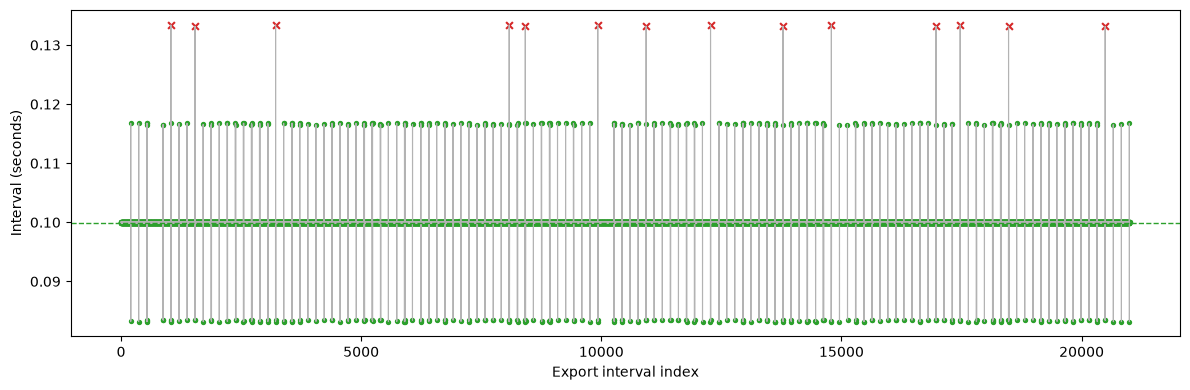

In [28]:
retained_edge_color = "tab:green"
deleted_edge_color = "tab:red"
inferred_edge_color = "tab:purple"
normal_interval_color = "tab:green"
abnormal_interval_color = "tab:red"

abnormal_interval_mask = (
    np.abs(
        exported_on_list_intervals_seconds
        - typical_edge_interval_seconds
    )
    > typical_interval_tolerance_fraction
    * typical_edge_interval_seconds
)
normal_interval_indices = np.flatnonzero(
    ~abnormal_interval_mask
)
abnormal_interval_indices = np.flatnonzero(
    abnormal_interval_mask
)

figure, interval_axis = plt.subplots(figsize=(12, 4))
figure.patch.set_facecolor("white")
interval_axis.set_facecolor("white")
interval_axis.plot(
    exported_on_list_intervals_seconds,
    color="0.70",
    linewidth=0.8,
    label="Interval sequence",
)
interval_axis.scatter(
    normal_interval_indices,
    exported_on_list_intervals_seconds[normal_interval_indices],
    color=normal_interval_color,
    s=8,
    label="Normal interval",
)
interval_axis.axhline(
    typical_edge_interval_seconds,
    color=normal_interval_color,
    linewidth=1.0,
    linestyle="--",
    label="Typical interval",
)
interval_axis.scatter(
    abnormal_interval_indices,
    exported_on_list_intervals_seconds[abnormal_interval_indices],
    color=abnormal_interval_color,
    marker="x",
    s=24,
    label="Abnormal interval",
)
interval_axis.set_xlabel("Export interval index")
interval_axis.set_ylabel("Interval (seconds)")
figure.tight_layout()
plt.show()


Local plots cover HIGH-run removal, boundary trim, gap repair, and every remaining short/long measured interval.
Local event context: +/-0.499459 seconds (5 typical intervals).
Boundary comparison context: +/-1.000 seconds.
End diagnostics include a full trim overview and a fixed-scale final-boundary detail.
LOW-gap fill collapsed 139452 raw crack transitions; they are summarized, not plotted one by one.
Diagnostic event count: 17
1: REVIEW interval group 1: trials 1039-1039; 0 SHORT, 1 LONG; measured timings preserved


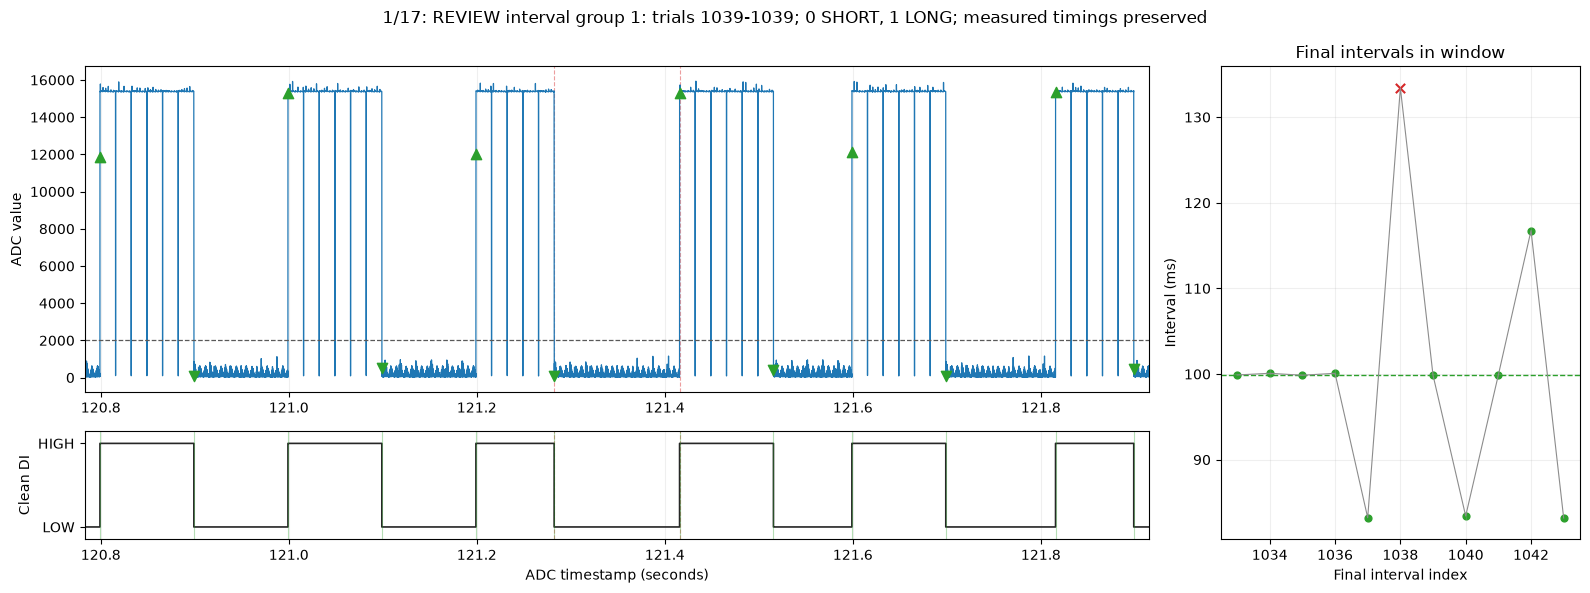

2: REVIEW interval group 2: trials 1542-1542; 0 SHORT, 1 LONG; measured timings preserved


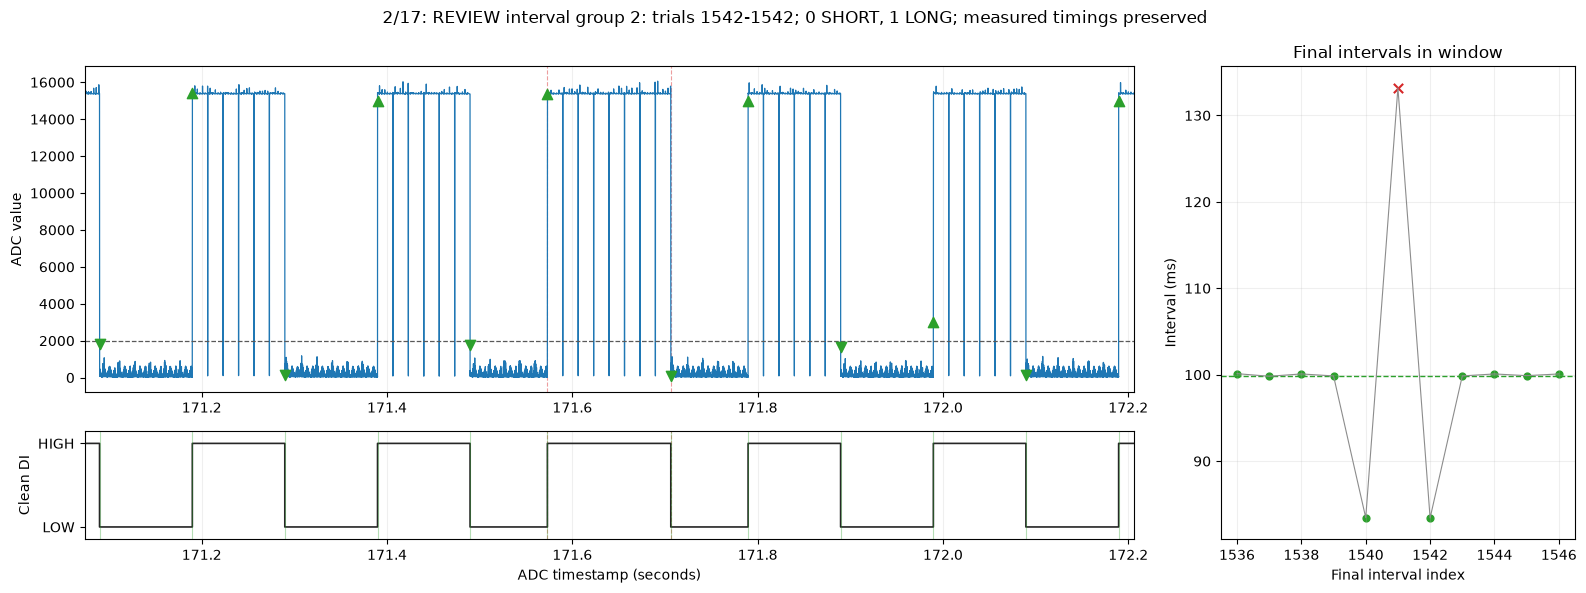

3: REVIEW interval group 3: trials 3219-3219; 0 SHORT, 1 LONG; measured timings preserved


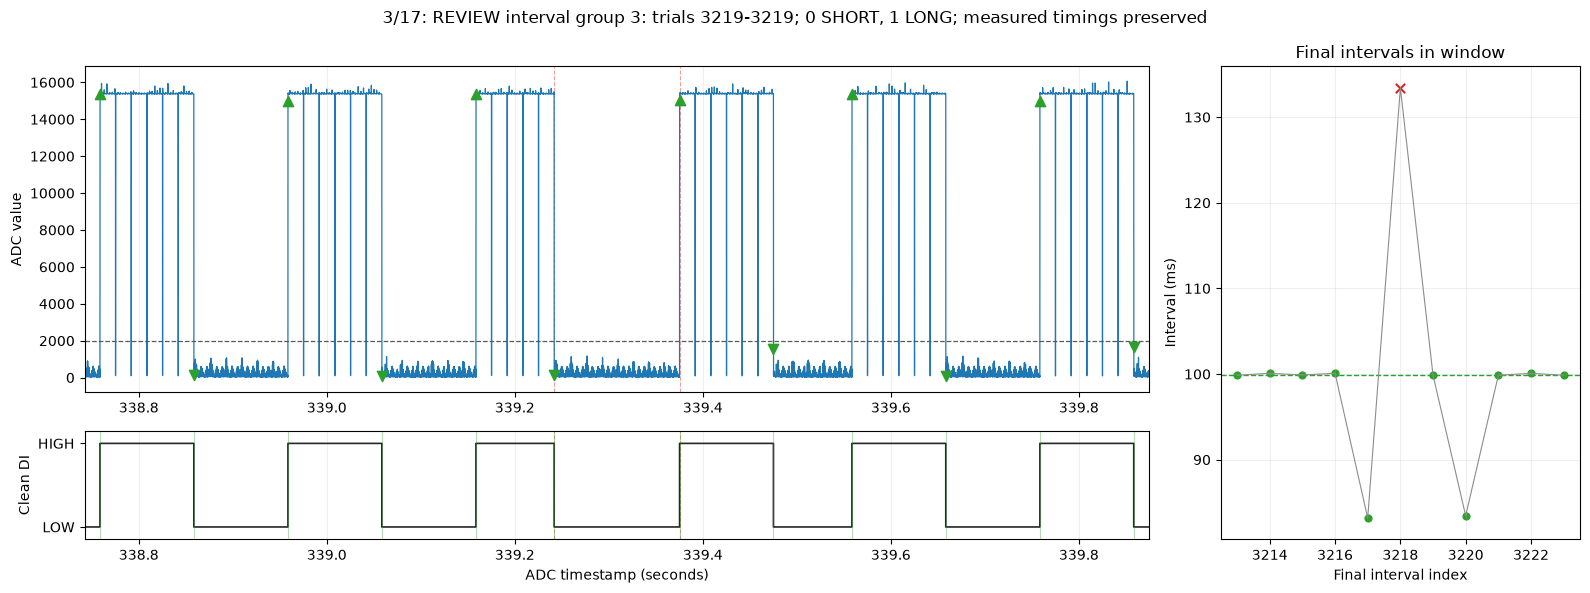

4: REVIEW interval group 4: trials 8083-8083; 0 SHORT, 1 LONG; measured timings preserved


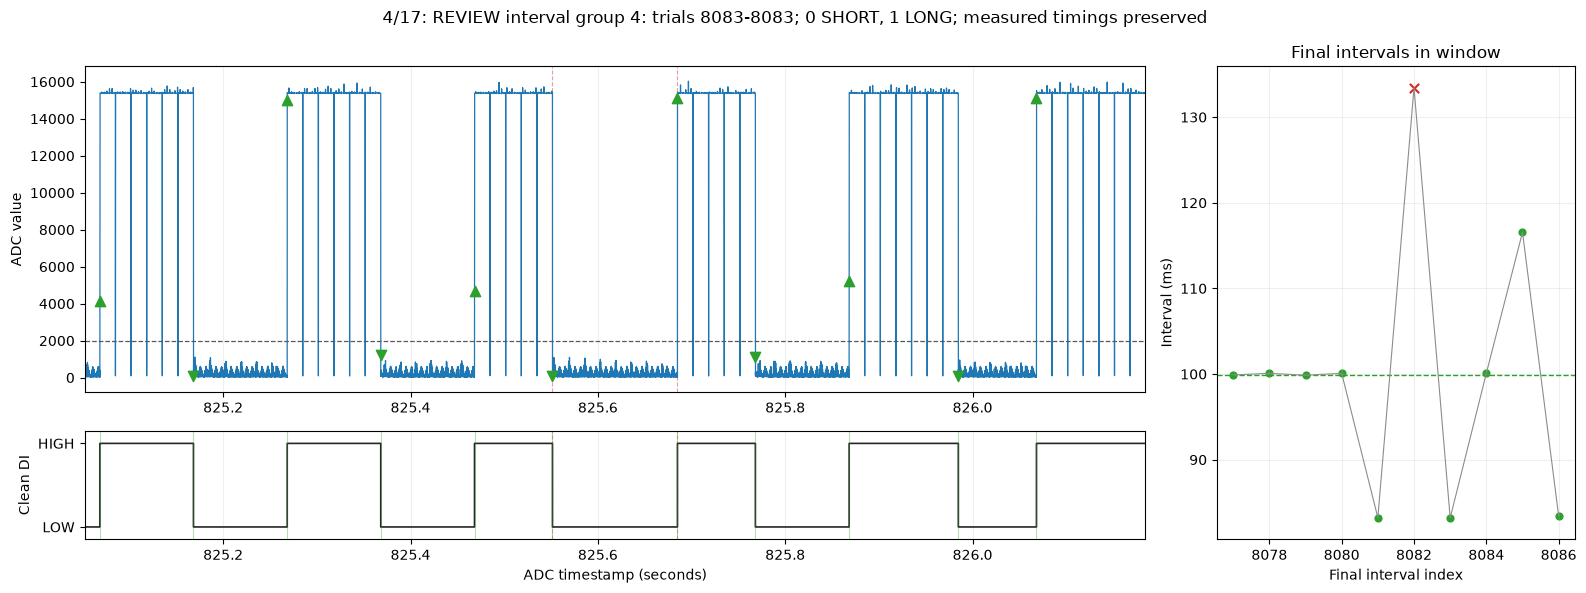

5: REVIEW interval group 5: trials 8418-8418; 0 SHORT, 1 LONG; measured timings preserved


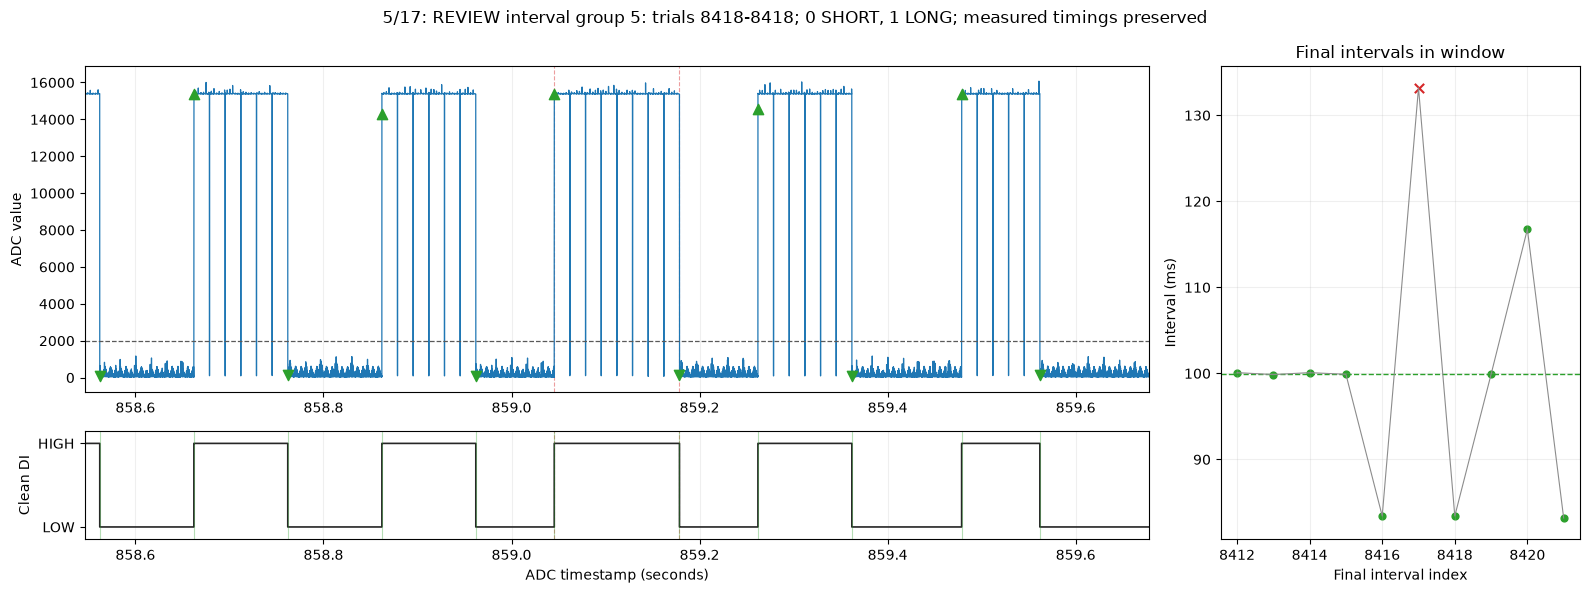

6: REVIEW interval group 6: trials 9927-9927; 0 SHORT, 1 LONG; measured timings preserved


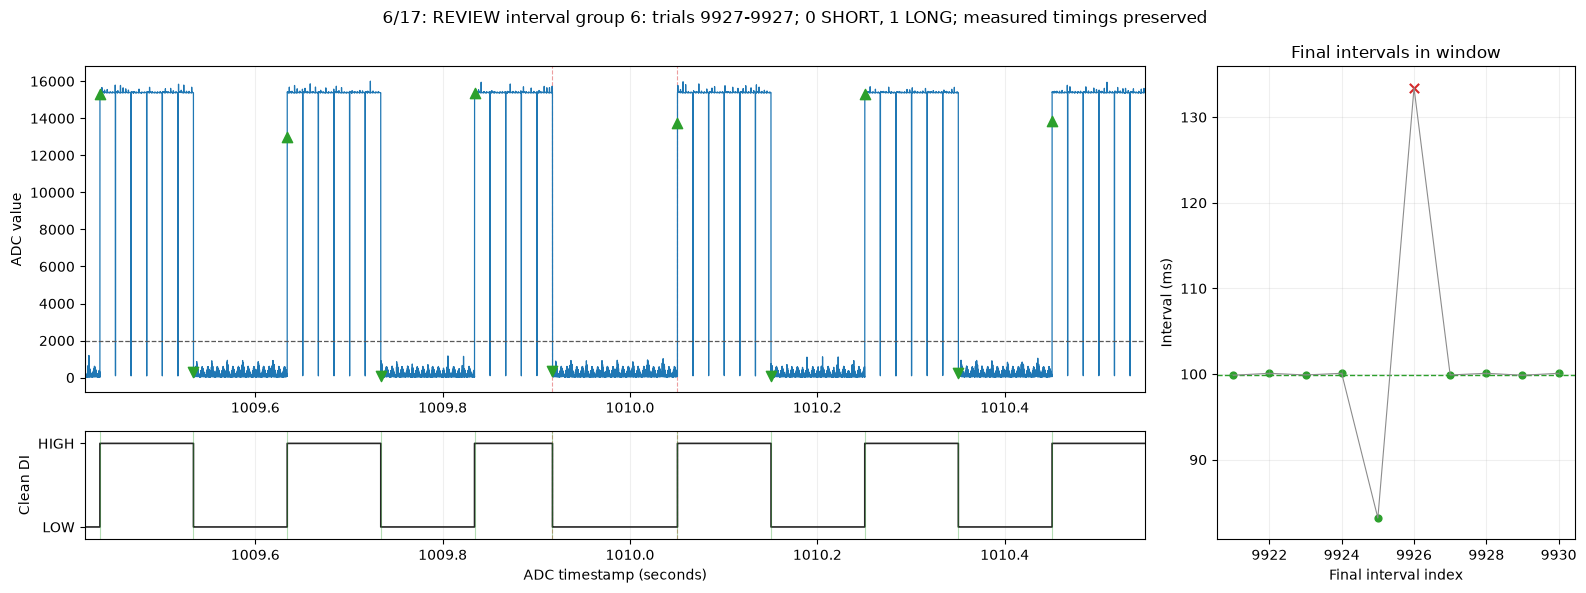

7: REVIEW interval group 7: trials 10934-10934; 0 SHORT, 1 LONG; measured timings preserved


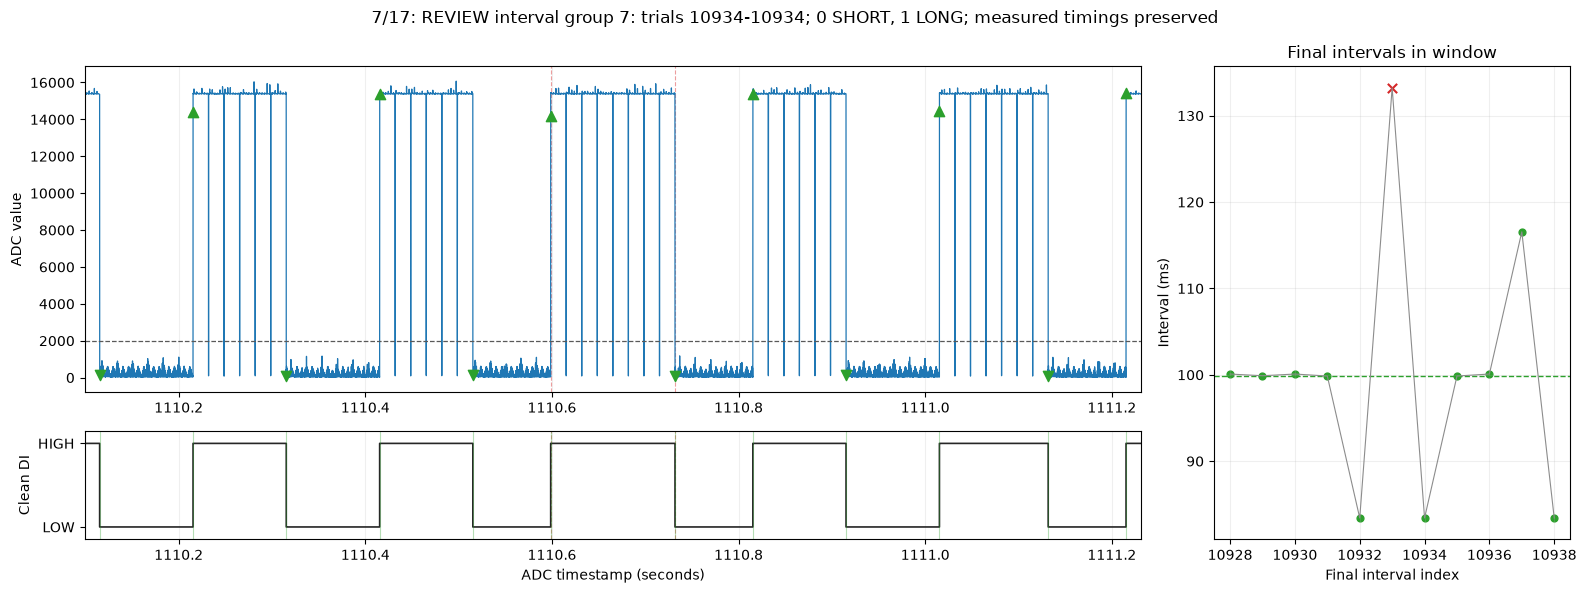

8: REVIEW interval group 8: trials 12275-12275; 0 SHORT, 1 LONG; measured timings preserved


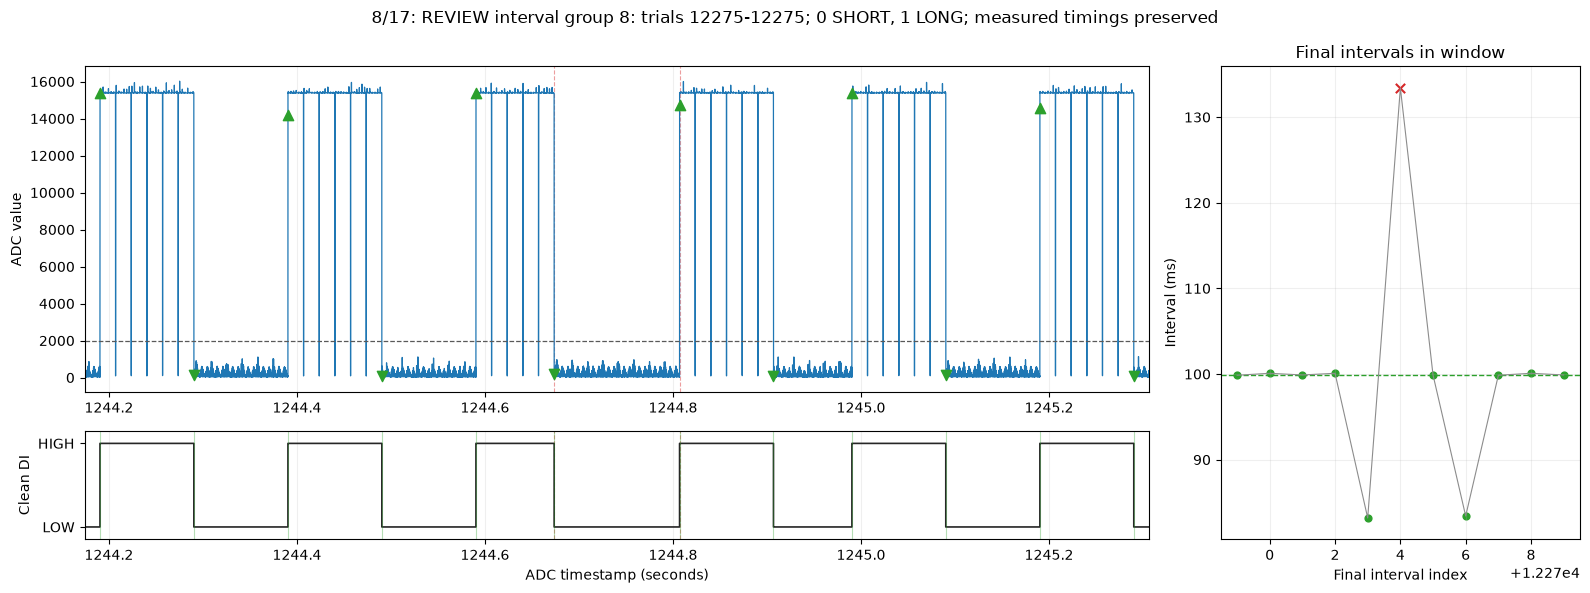

9: REVIEW interval group 9: trials 13784-13784; 0 SHORT, 1 LONG; measured timings preserved


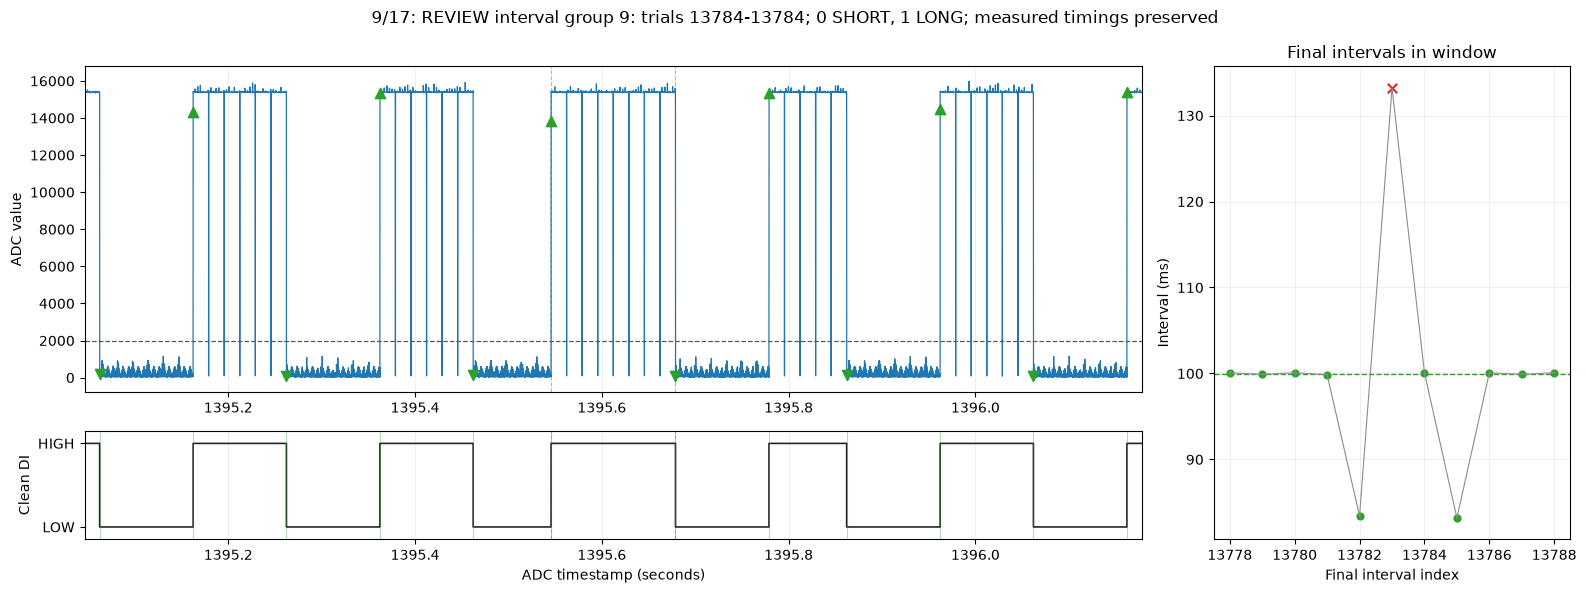

10: REVIEW interval group 10: trials 14791-14791; 0 SHORT, 1 LONG; measured timings preserved


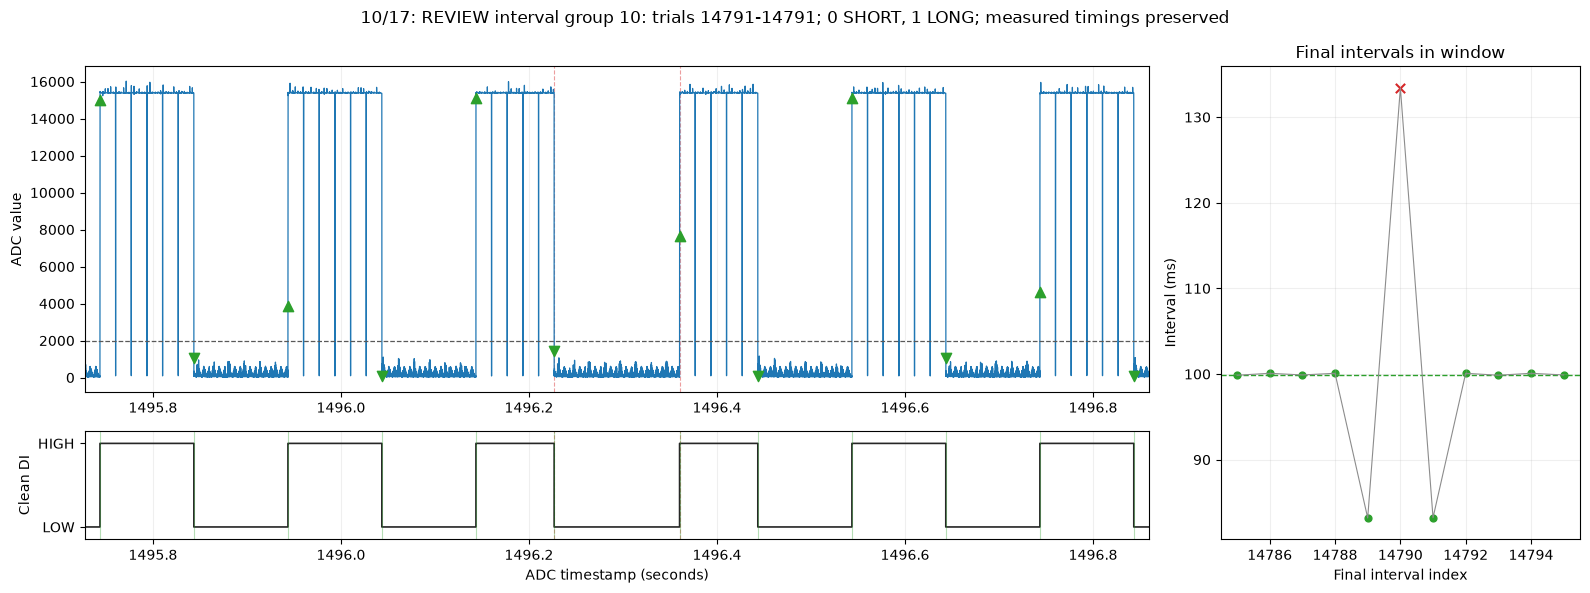

11: REVIEW interval group 11: trials 16970-16970; 0 SHORT, 1 LONG; measured timings preserved


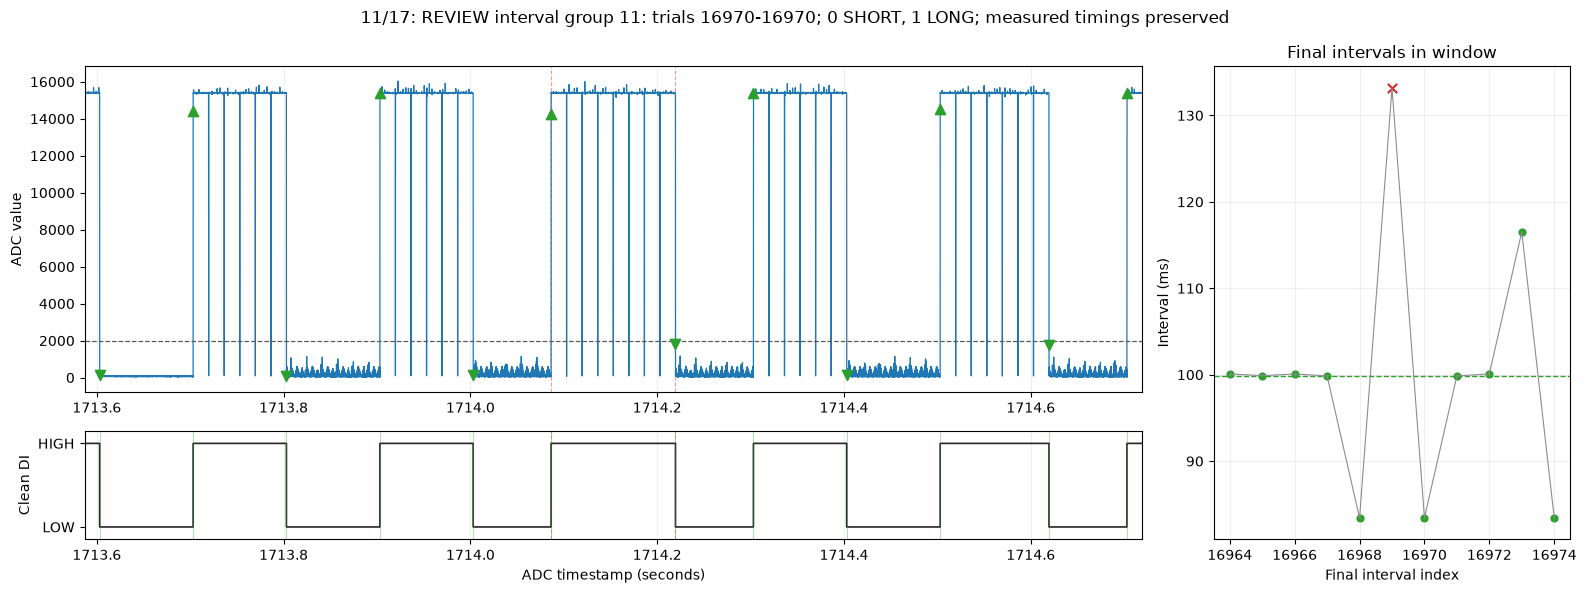

12: REVIEW interval group 12: trials 17473-17473; 0 SHORT, 1 LONG; measured timings preserved


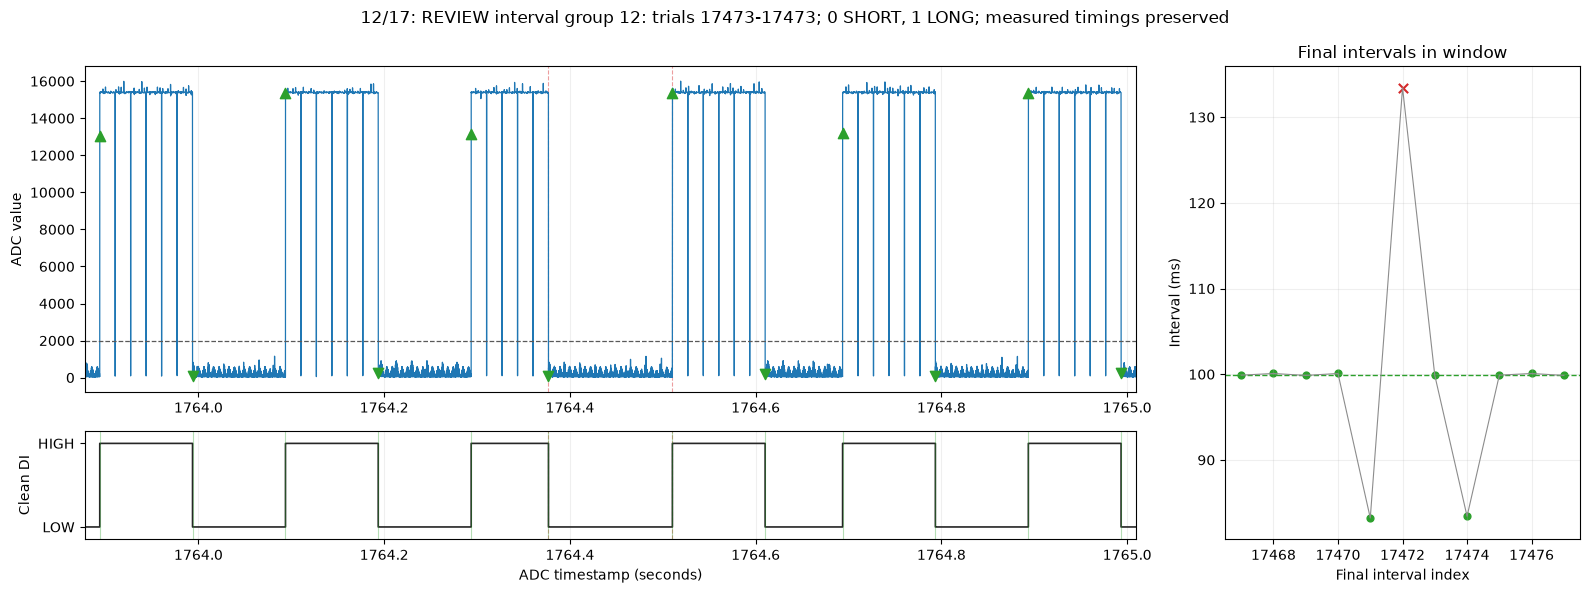

13: REVIEW interval group 13: trials 18480-18480; 0 SHORT, 1 LONG; measured timings preserved


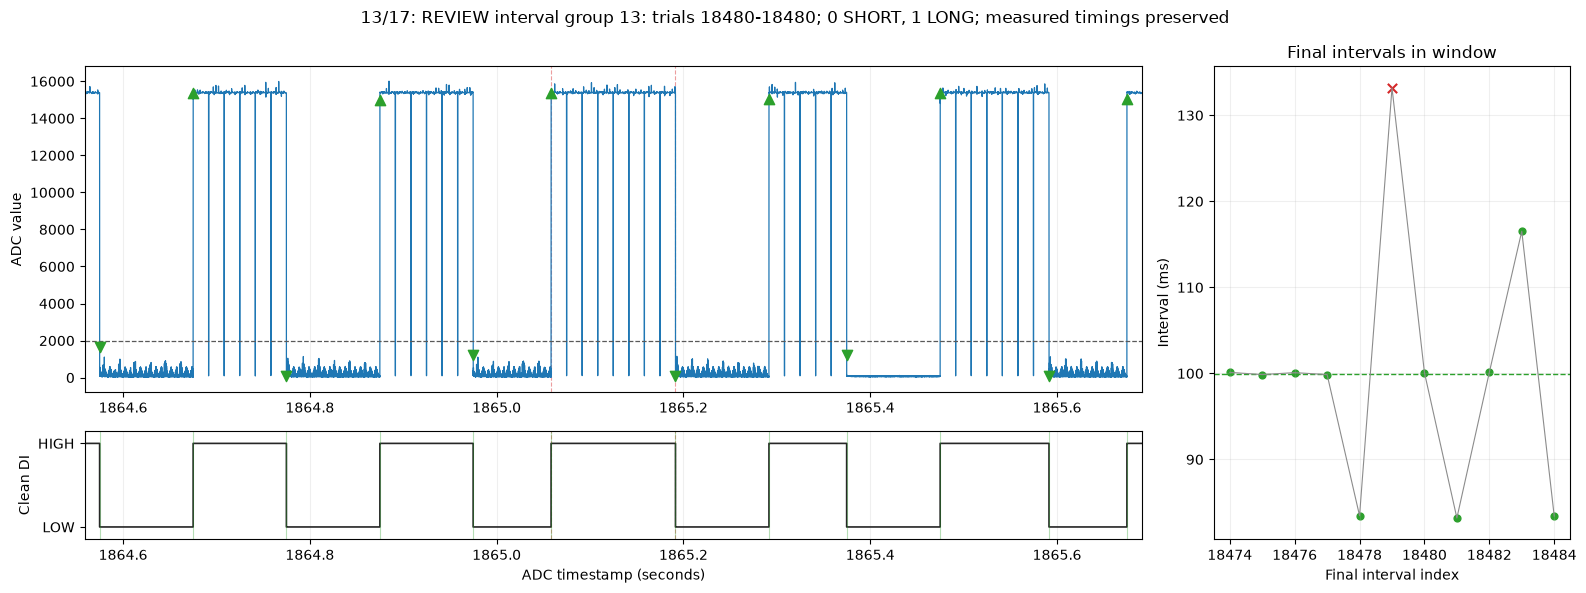

14: REVIEW interval group 14: trials 20492-20492; 0 SHORT, 1 LONG; measured timings preserved


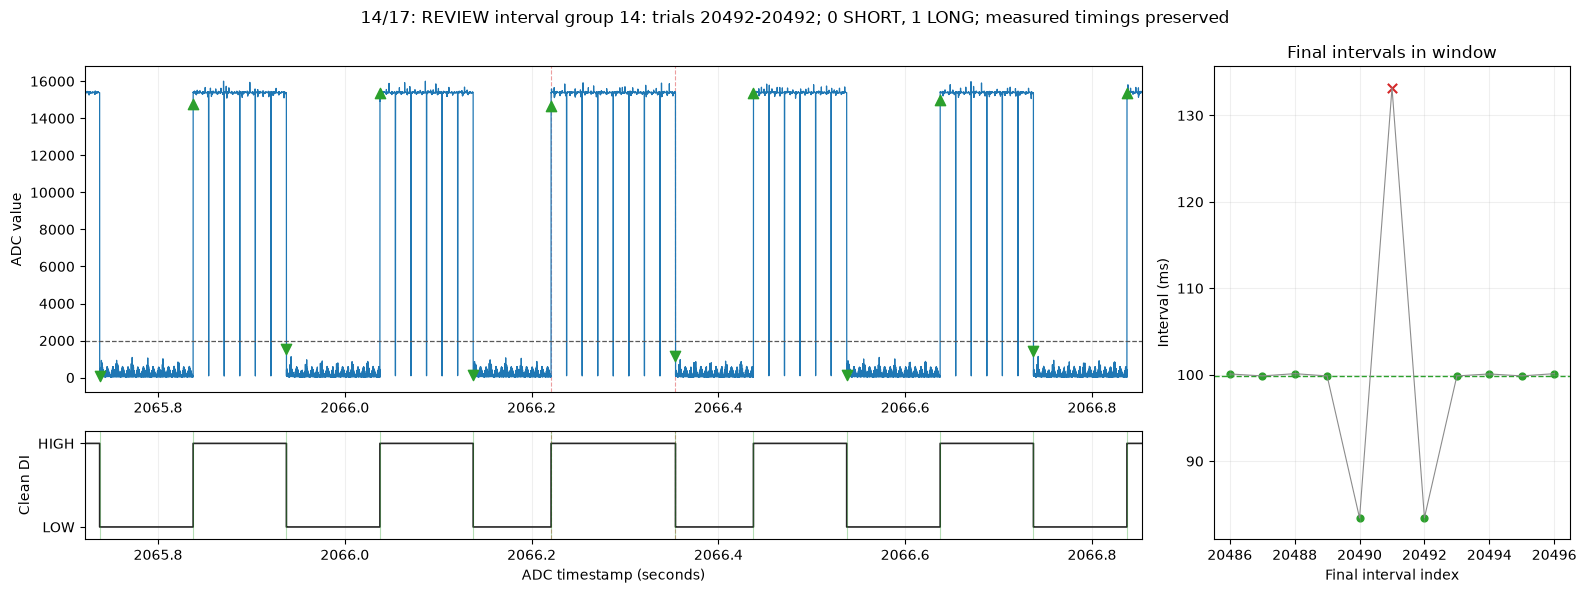

15: TRIM START: remove 3 measured edges; old first -> revised first


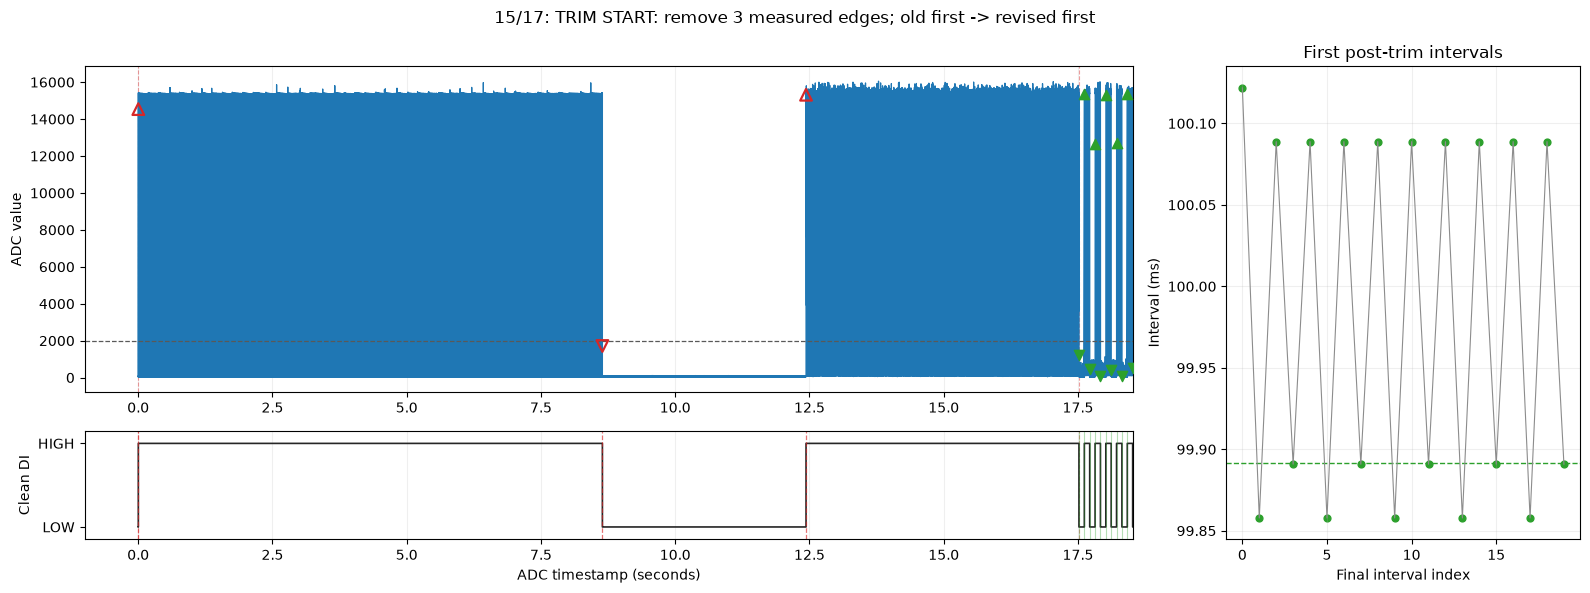

16: TRIM END OVERVIEW: remove 3 measured edges; revised final boundary -> old last


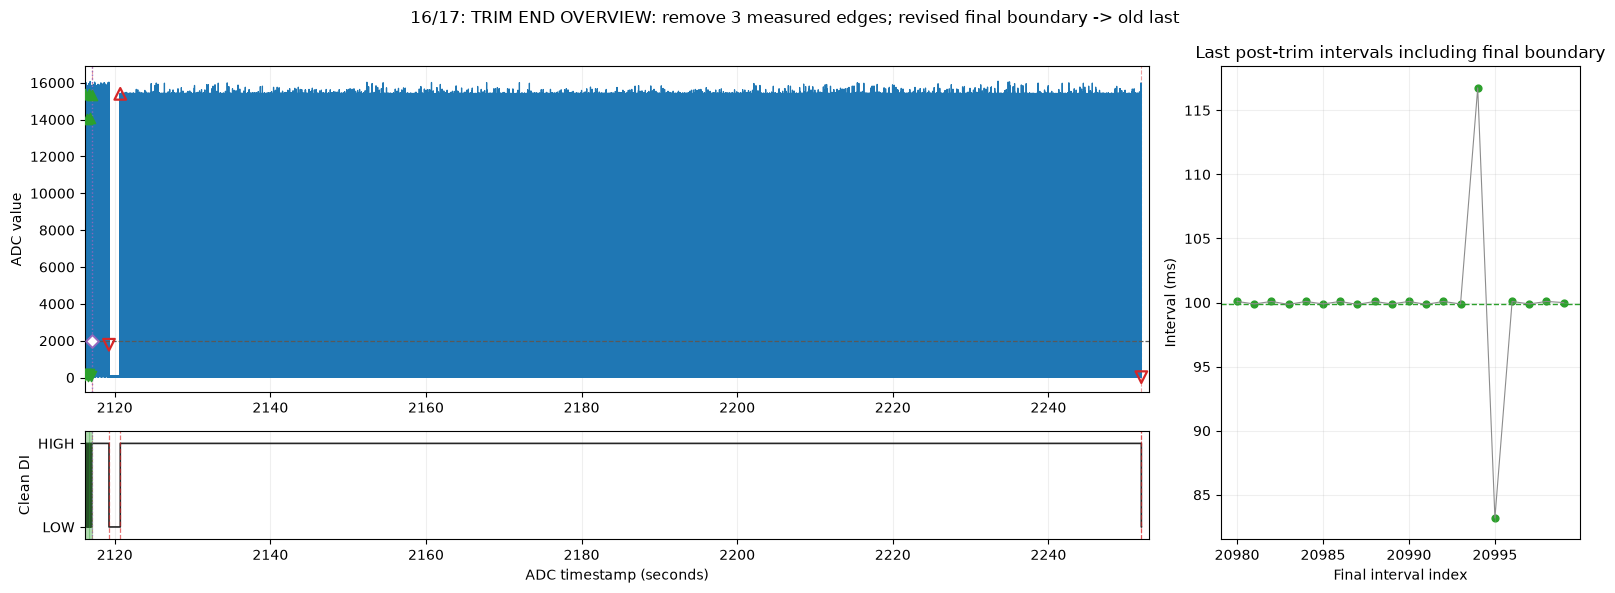

17: FINAL BOUNDARY DETAIL: measured rising -> synthetic falling; 100.000 ms


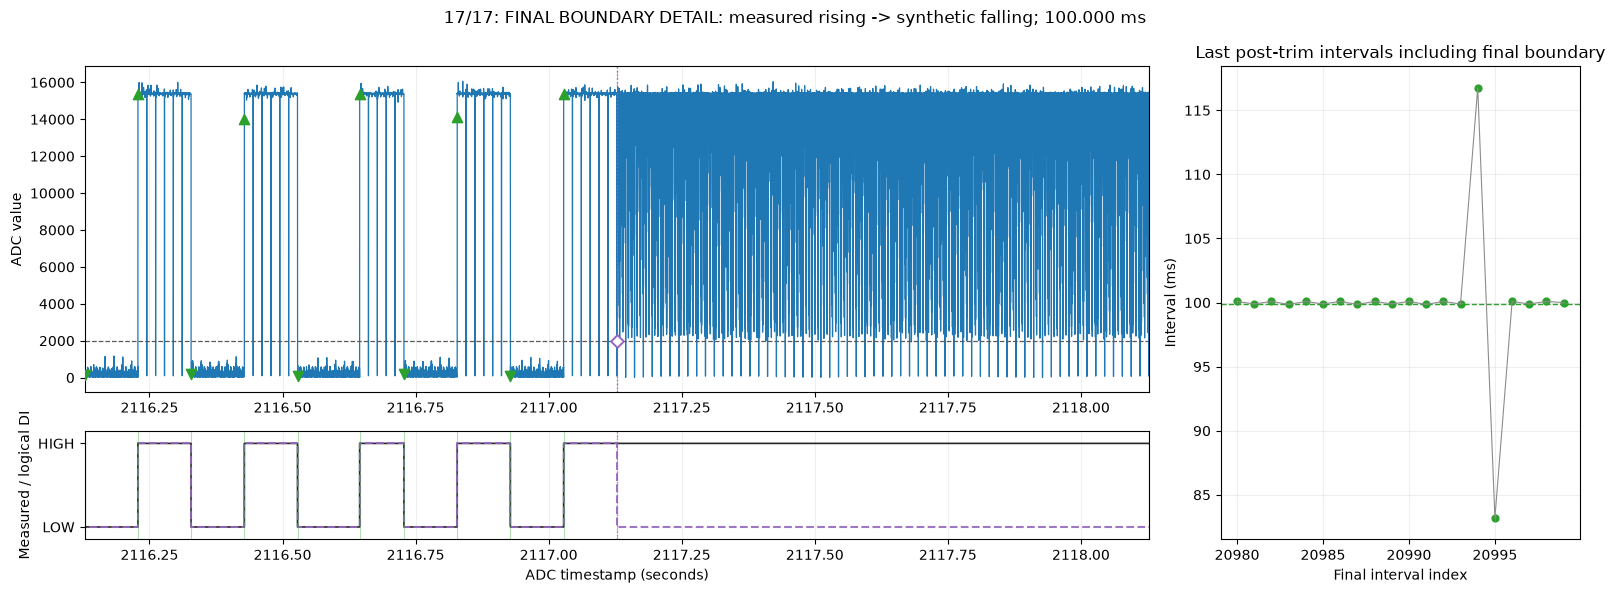

In [29]:
diagnostic_context_interval_count = 5
diagnostic_context_seconds = (
    diagnostic_context_interval_count
    * typical_edge_interval_seconds
)
diagnostic_events = []

for removed_high_run_start_position in range(
    0,
    len(removed_short_high_edge_sample_indices),
    2,
):
    removed_high_run_start_sample_index = int(
        removed_short_high_edge_sample_indices[
            removed_high_run_start_position
        ]
    )
    removed_high_run_end_sample_index = int(
        removed_short_high_edge_sample_indices[
            removed_high_run_start_position + 1
        ]
    )
    removed_high_run_start_time_seconds = float(
        ADC_continuous_time_stamp_data[
            removed_high_run_start_sample_index
        ]
    )
    removed_high_run_end_time_seconds = float(
        ADC_continuous_time_stamp_data[
            removed_high_run_end_sample_index
        ]
    )
    removed_high_run_duration_ms = (
        removed_high_run_end_time_seconds
        - removed_high_run_start_time_seconds
    ) * 1000
    removed_high_run_number = (
        removed_high_run_start_position // 2 + 1
    )

    diagnostic_events.append(
        {
            "title": (
                f"DELETE short HIGH run {removed_high_run_number}: "
                "2 measured edges, "
                f"{removed_high_run_duration_ms:.3f} ms"
            ),
            "window_start_time_seconds": (
                removed_high_run_start_time_seconds
                - diagnostic_context_seconds
            ),
            "window_end_time_seconds": (
                removed_high_run_end_time_seconds
                + diagnostic_context_seconds
            ),
            "highlight_start_time_seconds": (
                removed_high_run_start_time_seconds
            ),
            "highlight_end_time_seconds": (
                removed_high_run_end_time_seconds
            ),
            "highlight_color": deleted_edge_color,
            "highlight_label": "Removed HIGH span",
        }
    )

for gap_repair_number, gap_repair_information in enumerate(
    applied_gap_repairs,
    start=1,
):
    left_anchor_time_seconds = float(
        ADC_continuous_time_stamp_data[
            gap_repair_information["left_anchor_sample_index"]
        ]
    )
    right_anchor_time_seconds = float(
        ADC_continuous_time_stamp_data[
            gap_repair_information["right_anchor_sample_index"]
        ]
    )
    removed_measured_interior_edge_count = (
        gap_repair_information["observed_interval_count"] - 1
    )
    inferred_interior_edge_count = (
        gap_repair_information["expected_interval_count"] - 1
    )

    diagnostic_events.append(
        {
            "title": (
                f"REPLACE gap {gap_repair_number}: "
                f"{gap_repair_information['observed_interval_count']} "
                "-> "
                f"{gap_repair_information['expected_interval_count']} intervals; "
                f"delete {removed_measured_interior_edge_count} measured, "
                f"infer {inferred_interior_edge_count}, net "
                f"{gap_repair_information['net_transition_count_change']:+d}"
            ),
            "window_start_time_seconds": (
                left_anchor_time_seconds
                - diagnostic_context_seconds
            ),
            "window_end_time_seconds": (
                right_anchor_time_seconds
                + diagnostic_context_seconds
            ),
            "highlight_start_time_seconds": (
                left_anchor_time_seconds
            ),
            "highlight_end_time_seconds": (
                right_anchor_time_seconds
            ),
            "highlight_color": inferred_edge_color,
            "highlight_label": "Interpolated anchor span",
        }
    )

# Group adjacent flagged intervals so a long/short pair appears in the same raw-trace plot.
if len(interval_qc_flagged_indices):
    interval_qc_groups = np.split(
        interval_qc_flagged_indices,
        np.flatnonzero(np.diff(interval_qc_flagged_indices) > 1) + 1,
    )
else:
    interval_qc_groups = []

for group_number, interval_group in enumerate(interval_qc_groups, start=1):
    first_interval = int(interval_group[0])
    last_interval = int(interval_group[-1])
    flagged_start_time = float(on_list_time[first_interval])
    flagged_end_time = float(on_list_time[last_interval + 1])
    short_count = int(np.count_nonzero(interval_qc_short_mask[interval_group]))
    long_count = len(interval_group) - short_count
    diagnostic_events.append({
        "title": (
            f"REVIEW interval group {group_number}: trials {first_interval + 1}-{last_interval + 1}; "
            f"{short_count} SHORT, {long_count} LONG; measured timings preserved"
        ),
        "window_start_time_seconds": flagged_start_time - diagnostic_context_seconds,
        "window_end_time_seconds": flagged_end_time + diagnostic_context_seconds,
        "highlight_start_time_seconds": flagged_start_time,
        "highlight_end_time_seconds": flagged_end_time,
        "highlight_color": abnormal_interval_color,
        "highlight_label": "Flagged measured interval span",
    })

boundary_comparison_context_seconds = 1.0
if trim_start_count > 0:
    old_first_transition_time_seconds = float(transition_times[0])
    revised_first_transition_time_seconds = float(on_list_time[0])
    diagnostic_events.append(
        {
            "title": (
                f"TRIM START: remove {trim_start_count} measured "
                "edges; old first -> revised first"
            ),
            "window_start_time_seconds": (
                old_first_transition_time_seconds
                - boundary_comparison_context_seconds
            ),
            "window_end_time_seconds": (
                revised_first_transition_time_seconds
                + boundary_comparison_context_seconds
            ),
            "interval_indices": np.arange(
                periodic_support_interval_count
            ),
            "interval_title": (
                "First post-trim intervals"
            ),
            "highlight_start_time_seconds": (
                old_first_transition_time_seconds
            ),
            "highlight_end_time_seconds": (
                revised_first_transition_time_seconds
            ),
            "highlight_color": deleted_edge_color,
            "highlight_label": "Removed start span",
        }
    )

revised_last_boundary_time_seconds = float(
    on_list_time_for_export[-1]
)
last_retained_edge_direction_label = (
    "rising"
    if on_list_edge_directions[-1] == 1
    else "falling"
)
final_boundary_direction_label = (
    "rising"
    if final_boundary_direction == 1
    else "falling"
)
last_export_interval_indices = np.arange(
    len(exported_on_list_intervals_seconds)
    - periodic_support_interval_count,
    len(exported_on_list_intervals_seconds),
)

if trim_end_count > 0:
    old_last_transition_time_seconds = float(transition_times[-1])
    diagnostic_events.append(
        {
            "title": (
                f"TRIM END OVERVIEW: remove {trim_end_count} measured "
                "edges; revised final boundary -> old last"
            ),
            "window_start_time_seconds": (
                revised_last_boundary_time_seconds
                - boundary_comparison_context_seconds
            ),
            "window_end_time_seconds": (
                old_last_transition_time_seconds
                + boundary_comparison_context_seconds
            ),
            "interval_indices": last_export_interval_indices,
            "interval_title": (
                "Last post-trim intervals including final boundary"
            ),
            "additional_inferred_edge_times": np.array(
                [revised_last_boundary_time_seconds]
            ),
            "highlight_start_time_seconds": (
                revised_last_boundary_time_seconds
            ),
            "highlight_end_time_seconds": (
                old_last_transition_time_seconds
            ),
            "highlight_color": deleted_edge_color,
            "highlight_label": "Removed end span",
        }
    )

diagnostic_events.append(
    {
        "title": (
            "FINAL BOUNDARY DETAIL: measured "
            f"{last_retained_edge_direction_label} -> synthetic "
            f"{final_boundary_direction_label}; "
            f"{exported_on_list_intervals_seconds[-1] * 1000:.3f} ms"
        ),
        "window_start_time_seconds": (
            revised_last_boundary_time_seconds
            - boundary_comparison_context_seconds
        ),
        "window_end_time_seconds": (
            revised_last_boundary_time_seconds
            + boundary_comparison_context_seconds
        ),
        "interval_indices": last_export_interval_indices,
        "interval_title": (
            "Last post-trim intervals including final boundary"
        ),
        "additional_inferred_edge_times": np.array(
            [revised_last_boundary_time_seconds]
        ),
        "highlight_start_time_seconds": (
            revised_last_boundary_time_seconds
        ),
        "highlight_end_time_seconds": (
            revised_last_boundary_time_seconds
            + boundary_comparison_context_seconds
        ),
        "highlight_color": deleted_edge_color,
        "highlight_label": "Outside exported trial block",
        "show_export_digital_state": True,
    }
)

print(
    "Local plots cover HIGH-run removal, boundary trim, "
    "gap repair, and every remaining short/long measured interval."
)
print(
    "Local event context: +/-"
    f"{diagnostic_context_seconds:.6f} seconds "
    f"({diagnostic_context_interval_count} typical intervals)."
)
print(
    "Boundary comparison context: +/-"
    f"{boundary_comparison_context_seconds:.3f} seconds."
)
print(
    "End diagnostics include a full trim overview and a "
    "fixed-scale final-boundary detail."
)
print(
    "LOW-gap fill collapsed "
    f"{raw_transition_count - len(filled_transition_sample_indices)} "
    "raw crack transitions; they are summarized, not plotted "
    "one by one."
)

plt.close("all")

high_run_plots = [
    event for event in diagnostic_events
    if event["title"].startswith("DELETE short HIGH run")
]
review_plots = [
    event for event in diagnostic_events
    if not event["title"].startswith("DELETE short HIGH run")
]

diagnostic_events = review_plots + high_run_plots[:5]

print(f"Diagnostic event count: {len(diagnostic_events)}")
for diagnostic_event_number, diagnostic_event in enumerate(
    diagnostic_events,
    start=1,
):
    print(
        f"{diagnostic_event_number}: "
        f"{diagnostic_event['title']}"
    )

    diagnostic_start_time_seconds = diagnostic_event[
        "window_start_time_seconds"
    ]
    diagnostic_end_time_seconds = diagnostic_event[
        "window_end_time_seconds"
    ]
    diagnostic_start_sample_index = np.searchsorted(
        ADC_timestamp_search_axis,
        diagnostic_start_time_seconds,
        side="left",
    )
    diagnostic_end_sample_index = np.searchsorted(
        ADC_timestamp_search_axis,
        diagnostic_end_time_seconds,
        side="right",
    )

    diagnostic_time = ADC_continuous_time_stamp_data[
        diagnostic_start_sample_index:diagnostic_end_sample_index
    ]
    diagnostic_photodiode_data = photodiode_data[
        diagnostic_start_sample_index:diagnostic_end_sample_index
    ]
    diagnostic_clean_digital_data = photodiode_is_high_clean[
        diagnostic_start_sample_index:diagnostic_end_sample_index
    ]

    visible_observed_edge_mask = (
        (
            final_observed_transition_sample_indices
            >= diagnostic_start_sample_index
        )
        & (
            final_observed_transition_sample_indices
            < diagnostic_end_sample_index
        )
    )
    visible_observed_edge_sample_indices = (
        final_observed_transition_sample_indices[
            visible_observed_edge_mask
        ]
    )
    visible_observed_edge_times = (
        ADC_continuous_time_stamp_data[
            visible_observed_edge_sample_indices
        ]
    )
    visible_observed_edge_directions = (
        clean_digital_state_changes[
            visible_observed_edge_sample_indices - 1
        ]
    )
    visible_rising_edge_mask = (
        visible_observed_edge_directions == 1
    )
    visible_falling_edge_mask = (
        visible_observed_edge_directions == -1
    )

    visible_deleted_edge_mask = (
        (
            automatically_deleted_edge_sample_indices
            >= diagnostic_start_sample_index
        )
        & (
            automatically_deleted_edge_sample_indices
            < diagnostic_end_sample_index
        )
    )
    visible_deleted_edge_sample_indices = (
        automatically_deleted_edge_sample_indices[
            visible_deleted_edge_mask
        ]
    )
    visible_deleted_edge_times = (
        ADC_continuous_time_stamp_data[
            visible_deleted_edge_sample_indices
        ]
    )
    visible_deleted_edge_directions = (
        automatically_deleted_edge_directions[
            visible_deleted_edge_mask
        ]
    )
    visible_deleted_rising_edge_mask = (
        visible_deleted_edge_directions == 1
    )
    visible_deleted_falling_edge_mask = (
        visible_deleted_edge_directions == -1
    )

    diagnostic_inferred_edge_times = interpolated_edge_times
    if "additional_inferred_edge_times" in diagnostic_event:
        diagnostic_inferred_edge_times = np.concatenate(
            (
                diagnostic_inferred_edge_times,
                diagnostic_event["additional_inferred_edge_times"],
            )
        )
    visible_inferred_edge_times = diagnostic_inferred_edge_times[
        (
            diagnostic_inferred_edge_times
            >= diagnostic_start_time_seconds
        )
        & (
            diagnostic_inferred_edge_times
            <= diagnostic_end_time_seconds
        )
    ]

    show_export_digital_state = diagnostic_event.get(
        "show_export_digital_state",
        False,
    )
    if show_export_digital_state:
        first_visible_export_boundary_index = int(
            np.searchsorted(
                on_list_time_for_export,
                diagnostic_start_time_seconds,
                side="left",
            )
        )
        export_boundary_stop_index = int(
            np.searchsorted(
                on_list_time_for_export,
                diagnostic_end_time_seconds,
                side="right",
            )
        )
        visible_export_boundary_times = on_list_time_for_export[
            first_visible_export_boundary_index:
            export_boundary_stop_index
        ]
        visible_export_boundary_directions = (
            on_list_edge_directions_for_export[
                first_visible_export_boundary_index:
                export_boundary_stop_index
            ]
        )

        if first_visible_export_boundary_index == 0:
            export_state_at_window_start = int(
                on_list_edge_directions_for_export[0] == -1
            )
        else:
            export_state_at_window_start = int(
                on_list_edge_directions_for_export[
                    first_visible_export_boundary_index - 1
                ]
                == 1
            )

        export_states_after_visible_boundaries = (
            visible_export_boundary_directions == 1
        ).astype(np.int8)
        export_state_at_window_end = (
            int(export_states_after_visible_boundaries[-1])
            if len(export_states_after_visible_boundaries) > 0
            else export_state_at_window_start
        )
        export_digital_plot_times = np.concatenate(
            (
                [diagnostic_start_time_seconds],
                visible_export_boundary_times,
                [diagnostic_end_time_seconds],
            )
        )
        export_digital_plot_states = np.concatenate(
            (
                [export_state_at_window_start],
                export_states_after_visible_boundaries,
                [export_state_at_window_end],
            )
        )

    if "interval_indices" in diagnostic_event:
        diagnostic_interval_indices = diagnostic_event[
            "interval_indices"
        ]
        diagnostic_interval_title = diagnostic_event[
            "interval_title"
        ]
    else:
        diagnostic_interval_indices = np.flatnonzero(
            (
                on_list_time_for_export[:-1]
                >= diagnostic_start_time_seconds
            )
            & (
                on_list_time_for_export[1:]
                <= diagnostic_end_time_seconds
            )
        )
        diagnostic_interval_title = "Final intervals in window"

    diagnostic_interval_seconds = exported_on_list_intervals_seconds[
        diagnostic_interval_indices
    ]
    diagnostic_interval_milliseconds = (
        diagnostic_interval_seconds * 1000
    )
    diagnostic_interval_is_abnormal = (
        np.abs(
            diagnostic_interval_seconds
            - typical_edge_interval_seconds
        )
        > typical_interval_tolerance_fraction
        * typical_edge_interval_seconds
    )

    figure = plt.figure(figsize=(16, 6))
    diagnostic_grid = figure.add_gridspec(
        2,
        2,
        width_ratios=[4, 1.35],
        height_ratios=[3, 1],
    )
    ADC_axis = figure.add_subplot(diagnostic_grid[0, 0])
    digital_axis = figure.add_subplot(
        diagnostic_grid[1, 0],
        sharex=ADC_axis,
    )
    interval_axis = figure.add_subplot(diagnostic_grid[:, 1])
    figure.patch.set_facecolor("white")
    for diagnostic_axis in (
        ADC_axis,
        digital_axis,
        interval_axis,
    ):
        diagnostic_axis.set_facecolor("white")
    figure.suptitle(
        f"{diagnostic_event_number}/{len(diagnostic_events)}: "
        f"{diagnostic_event['title']}"
    )

    for diagnostic_highlight_time_seconds in (
        diagnostic_event["highlight_start_time_seconds"],
        diagnostic_event["highlight_end_time_seconds"],
    ):
        ADC_axis.axvline(
            diagnostic_highlight_time_seconds,
            color=diagnostic_event["highlight_color"],
            linewidth=0.8,
            linestyle="--",
            alpha=0.45,
        )
        digital_axis.axvline(
            diagnostic_highlight_time_seconds,
            color=diagnostic_event["highlight_color"],
            linewidth=0.8,
            linestyle="--",
            alpha=0.45,
        )

    ADC_axis.plot(
        diagnostic_time,
        diagnostic_photodiode_data,
        color="C0",
        linewidth=0.9,
        label="Raw ADC",
    )
    ADC_axis.axhline(
        edge_threshold,
        color="0.35",
        linewidth=0.9,
        linestyle="--",
        label="Edge threshold",
    )
    ADC_axis.scatter(
        visible_observed_edge_times[visible_rising_edge_mask],
        photodiode_data[
            visible_observed_edge_sample_indices[
                visible_rising_edge_mask
            ]
        ],
        color=retained_edge_color,
        marker="^",
        s=55,
        zorder=5,
        label="Retained rising edge",
    )
    ADC_axis.scatter(
        visible_observed_edge_times[visible_falling_edge_mask],
        photodiode_data[
            visible_observed_edge_sample_indices[
                visible_falling_edge_mask
            ]
        ],
        color=retained_edge_color,
        marker="v",
        s=55,
        zorder=5,
        label="Retained falling edge",
    )
    ADC_axis.scatter(
        visible_deleted_edge_times[
            visible_deleted_rising_edge_mask
        ],
        photodiode_data[
            visible_deleted_edge_sample_indices[
                visible_deleted_rising_edge_mask
            ]
        ],
        facecolors="none",
        edgecolors=deleted_edge_color,
        linewidths=1.6,
        marker="^",
        s=70,
        zorder=6,
        label="Deleted rising edge",
    )
    ADC_axis.scatter(
        visible_deleted_edge_times[
            visible_deleted_falling_edge_mask
        ],
        photodiode_data[
            visible_deleted_edge_sample_indices[
                visible_deleted_falling_edge_mask
            ]
        ],
        facecolors="none",
        edgecolors=deleted_edge_color,
        linewidths=1.6,
        marker="v",
        s=70,
        zorder=6,
        label="Deleted falling edge",
    )

    for inferred_edge_number, inferred_edge_time in (
        enumerate(visible_inferred_edge_times)
    ):
        ADC_axis.axvline(
            inferred_edge_time,
            color=inferred_edge_color,
            linewidth=1.0,
            linestyle=":",
            alpha=0.9,
            label=(
                "Inferred edge or boundary (not measured)"
                if inferred_edge_number == 0
                else None
            ),
        )

    ADC_axis.scatter(
        visible_inferred_edge_times,
        np.full(len(visible_inferred_edge_times), edge_threshold),
        facecolors="white",
        edgecolors=inferred_edge_color,
        linewidths=1.4,
        marker="D",
        s=42,
        zorder=7,
    )

    digital_axis.step(
        diagnostic_time,
        diagnostic_clean_digital_data.astype(np.int8),
        where="post",
        color="0.15",
        linewidth=1.2,
        label="Measured clean DI",
    )
    if show_export_digital_state:
        digital_axis.step(
            export_digital_plot_times,
            export_digital_plot_states,
            where="post",
            color=inferred_edge_color,
            linewidth=1.5,
            linestyle="--",
            alpha=0.9,
            label="Logical export DI",
        )
    for observed_edge_time in visible_observed_edge_times:
        digital_axis.axvline(
            observed_edge_time,
            color=retained_edge_color,
            linewidth=0.8,
            alpha=0.35,
        )
    for deleted_edge_time in visible_deleted_edge_times:
        digital_axis.axvline(
            deleted_edge_time,
            color=deleted_edge_color,
            linewidth=0.9,
            linestyle="--",
            alpha=0.65,
        )
    for inferred_edge_time in visible_inferred_edge_times:
        digital_axis.axvline(
            inferred_edge_time,
            color=inferred_edge_color,
            linewidth=0.9,
            linestyle=":",
            alpha=0.75,
        )

    typical_edge_interval_milliseconds = (
        typical_edge_interval_seconds * 1000
    )
    interval_axis.axhline(
        typical_edge_interval_milliseconds,
        color=normal_interval_color,
        linewidth=1.0,
        linestyle="--",
        label="Typical interval",
    )
    interval_axis.plot(
        diagnostic_interval_indices,
        diagnostic_interval_milliseconds,
        color="0.55",
        linewidth=0.8,
    )
    interval_axis.scatter(
        diagnostic_interval_indices[
            ~diagnostic_interval_is_abnormal
        ],
        diagnostic_interval_milliseconds[
            ~diagnostic_interval_is_abnormal
        ],
        color=normal_interval_color,
        s=24,
        label="Normal",
    )
    interval_axis.scatter(
        diagnostic_interval_indices[
            diagnostic_interval_is_abnormal
        ],
        diagnostic_interval_milliseconds[
            diagnostic_interval_is_abnormal
        ],
        color=abnormal_interval_color,
        marker="x",
        s=45,
        label="Abnormal",
    )
    interval_axis.set_title(diagnostic_interval_title)
    interval_axis.set_xlabel("Final interval index")
    interval_axis.set_ylabel("Interval (ms)")
    interval_axis.grid(alpha=0.2)

    ADC_axis.set_ylabel("ADC value")
    ADC_axis.grid(axis="x", alpha=0.2)
    digital_axis.set_ylim(-0.15, 1.15)
    digital_axis.set_yticks([0, 1], labels=["LOW", "HIGH"])
    if show_export_digital_state:
        digital_axis.set_ylabel("Measured / logical DI")
    else:
        digital_axis.set_ylabel("Clean DI")
    digital_axis.set_xlabel("ADC timestamp (seconds)")
    digital_axis.ticklabel_format(
        axis="x",
        style="plain",
        useOffset=False,
    )
    digital_axis.set_xlim(
        diagnostic_start_time_seconds,
        diagnostic_end_time_seconds,
    )
    digital_axis.grid(axis="x", alpha=0.2)

    figure.tight_layout()
    plt.show()


In [30]:
# Review the diagnostic plots above before enabling is_save_on_list_time.
boundaries = np.asarray(on_list_time_for_export, dtype=np.float64)
if not (
    len(boundaries) == len(trials) + 1
    and np.isfinite(boundaries).all()
    and np.all(np.diff(boundaries) > 0)
    and boundaries[0] >= 0
    and boundaries[-1] <= session_duration_s
):
    raise ValueError("Trial boundaries must be increasing, inside session 4, and number N+1.")

on_list_time_output_file = stimulus_dir / "on_list_times.npy"
if is_save_on_list_time:
    if interval_qc_requires_review and not interval_anomalies_reviewed:
        raise ValueError(
            f"Saving paused: {len(interval_qc_flagged_indices)} measured intervals need review. "
            "Inspect all REVIEW interval group plots and confirm the first/last trial mapping. "
            "If the edges represent the actual stimulus timing, set interval_anomalies_reviewed = True "
            "and rerun. If edges were detected incorrectly, correct detection first."
        )
    stimulus_dir.mkdir(parents=True, exist_ok=True)
    # Preserve the last onset output before replacing it on a subsequent run.
    if on_list_time_output_file.exists():
        backup = stimulus_dir / "on_list_times.previous.npy"
        shutil.copy2(on_list_time_output_file, backup)
        print(f"Previous timing saved as: {backup}")
    temporary_output = stimulus_dir / "on_list_times.npy.tmp"
    with temporary_output.open("wb") as stream:
        np.save(stream, boundaries, allow_pickle=False)
    temporary_output.replace(on_list_time_output_file)
    trials_copy = stimulus_dir / trials_file.name
    shutil.copy2(trials_file, trials_copy)

    # Save detector edits and both clock origins for reproducible alignment.
    def encode_numpy(value):
        if isinstance(value, np.generic):
            return value.item()
        if isinstance(value, np.ndarray):
            return value.tolist()
        raise TypeError(f"Not JSON serializable: {type(value).__name__}")

    np.savez_compressed(
        stimulus_dir / "photodiode_timing_metadata.npz",
        session_number=np.int32(session_number),
        session_name=session_name,
        time_reference="session_local_adc_seconds",
        source_adc_file=str(ADC_datafile),
        source_adc_timestamps=str(ADC_continuous_time_stamp_file),
        source_structure_file=str(structure_file),
        source_trials_file=str(trials_file),
        source_session_info=str(session_info_file),
        adc_channel_index=np.int32(analogue_input_channel),
        adc_sample_rate_hz=np.float64(ADC_sampling_rate),
        adc_timestamp_nonfinite_count=np.int64(adc_timestamp_issue_counts["nonfinite samples"]),
        adc_timestamp_repeated_step_count=np.int64(adc_timestamp_issue_counts["repeated time steps"]),
        adc_timestamp_backward_step_count=np.int64(adc_timestamp_issue_counts["backward time steps"]),
        adc_timestamp_reversal_step_rows=adc_timestamp_reversal_step_rows,
        adc_timestamp_reversal_deltas_s=adc_timestamp_reversal_deltas_s,
        adc_timestamp_reversal_sample_numbers=adc_timestamp_reversal_sample_numbers,
        adc_timestamp_reversal_limit_s=np.float64(maximum_allowed_adc_timestamp_reversal_s),
        adc_timestamp_search_max_shift_s=np.float64(adc_timestamp_search_max_shift_s),
        adc_timestamp_search_modified_sample_count=np.int64(adc_timestamp_search_modified_sample_count),
        adc_timestamp_search_axis_use="diagnostic_plot_windows_only",
        measured_edge_time_source="original_ADC_timestamps_minus_first_timestamp",
        raw_adc_start_s=np.float64(raw_adc_start_s),
        adc_global_start_s=np.float64(adc_global_start_s),
        duration_s=np.float64(session_duration_s),
        n_trials=np.int64(len(trials)),
        n_boundaries=np.int64(len(boundaries)),
        interval_qc_typical_interval_s=np.float64(typical_edge_interval_seconds),
        interval_qc_tolerance_fraction=np.float64(typical_interval_tolerance_fraction),
        interval_qc_lower_bound_s=np.float64(interval_qc_lower_bound_s),
        interval_qc_upper_bound_s=np.float64(interval_qc_upper_bound_s),
        interval_qc_short_indices=short_interval_indices,
        interval_qc_long_indices=long_interval_indices,
        interval_qc_flagged_trial_numbers=interval_qc_flagged_indices + 1,
        interval_qc_measured_durations_s=on_list_edge_intervals_seconds[interval_qc_flagged_indices],
        interval_qc_review_confirmed=np.bool_(interval_anomalies_reviewed),
        interval_qc_measured_times_preserved=np.bool_(True),
        final_boundary_interval_s=np.float64(final_boundary_interval_seconds),
        final_boundary_inferred=np.bool_(True),
        boundary_edge_directions=on_list_edge_directions_for_export,
        automatic_edit_summary_json=json.dumps(automatic_edit_summary, default=encode_numpy),
    )
    print(f"Saved {len(boundaries):,} session-local ADC boundaries to {on_list_time_output_file}")
    print(f"Trial log copied to: {trials_copy}")
    print("Next RF inputs: these trial boundaries, this trial log, and session_04/neural/ProbeA spike arrays.")
else:
    print(f"Preview complete: {len(boundaries):,} boundaries; no files were saved.")
    print("Review first/last stimulus edges and every repaired gap against the raw trace.")
    if interval_qc_requires_review:
        print(
            "Inspect every REVIEW interval group plot. After confirming the actual stimulus timing, "
            "set interval_anomalies_reviewed = True and is_save_on_list_time = True; rerun all cells."
        )
    else:
        print("After review, set is_save_on_list_time = True in the parameter cell and rerun all cells.")


Saved 21,001 session-local ADC boundaries to R:\Basic_Sciences\Phys\SenzaiLab\Aparna\Data_by_mouse\m002\small-spread-neuropixel-config\2026-09-25\ad_session_2026_09_25\sessions\session_04\stimulus\on_list_times.npy
Trial log copied to: R:\Basic_Sciences\Phys\SenzaiLab\Aparna\Data_by_mouse\m002\small-spread-neuropixel-config\2026-09-25\ad_session_2026_09_25\sessions\session_04\stimulus\AD_headfixed_rfmapping_stationary_2026-9-25_RF_Mapping_Trials.mat
Next RF inputs: these trial boundaries, this trial log, and session_04/neural/ProbeA spike arrays.
